# Green-VRPTW (*Last-Mile Delivery*) dengan *Hybrid Genetic Search* (HGS) + 2‑Tier Lexicographic

## Fase 1: Persiapan Data & Peta

### Cell 0: Import Library & Konfigurasi Dasar (OSM Support) (Memuat library osmnx, networkx, folium, dan konfigurasi path direktori)

In [1]:
# ============================================
# 0. Import Library & Konfigurasi Dasar (FIXED KAGGLE)
# ============================================

# 1. Install Library Tambahan (Jika di Kaggle)
try:
    import osmnx
except ImportError:
    print("Installing osmnx...")
    !pip install -q osmnx folium matplotlib seaborn polyline

import math, json, random, itertools, time, sys, io, os
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Set, Tuple, Optional, Any, Callable
from collections import defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import folium
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX ERROR TQDM (Ini yang tadi hilang) ---
try:
    from tqdm.auto import tqdm
except ImportError:
    # Fallback dummy jika library tidak ada
    def tqdm(x, **kwargs): return x

# --- Reproducibility ---
RNGSEED = 42
random.seed(RNGSEED)
np.random.seed(RNGSEED)

# --- Pandas/Matplotlib config ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# ==============================================================================
# 🔧 PATH CONFIGURATION (KAGGLE SPECIFIC)
# ==============================================================================

# 1. DETEKSI FOLDER INPUT (READ-ONLY)
input_root = Path("/kaggle/input")
try:
    # Ambil nama folder dataset otomatis
    # (Kaggle kadang mengubah spasi jadi strip, jadi lebih aman auto-detect)
    dataset_candidates = [d for d in os.listdir(input_root) if os.path.isdir(input_root/d)]
    if dataset_candidates:
        DATASET_DIR = input_root / dataset_candidates[0]
        print(f"📂 INPUT DIR (Read-Only): {DATASET_DIR}")
    else:
        print("⚠️ Warning: Tidak ada folder di /kaggle/input. Cek 'Add Data'.")
        DATASET_DIR = Path(".")
except:
    DATASET_DIR = Path(".")

# 2. DEFINISI FOLDER OUTPUT (READ/WRITE)
OUTPUT_DIR = Path("/kaggle/working")
print(f"💾 OUTPUT DIR (Writable):  {OUTPUT_DIR}")

# --- MAPPING FILE (Pastikan nama file sesuai Dataset Anda) ---
# INPUT (Baca dari Dataset)
RAWRC101CSV     = DATASET_DIR / "RC101.csv"
RAWRC201CSV     = DATASET_DIR / "RC201.csv"
FLEETCONFIGJSON = DATASET_DIR / "fleet_three_types.json"

# OUTPUT (Simpan hasil proses ke Working Dir)
NODESRC101AUG   = OUTPUT_DIR / "nodes_aug_RC101.csv"
NODESRC201AUG   = OUTPUT_DIR / "nodes_aug_RC201.csv"
CORERC101NPZ    = OUTPUT_DIR / "solomon_core_RC101.npz"
CORERC201NPZ    = OUTPUT_DIR / "solomon_core_RC201.npz"

# --- KONFIGURASI GLOBAL ---
PLACE_NAME = "Surakarta, Indonesia"
NETWORK_TYPE = "drive"
REAL_SPEED_KMH = 40.0

print("="*40)
print("✅ KONFIGURASI & TQDM SIAP")

Installing osmnx...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 4.0 MB/s eta 0:00:00
📂 INPUT DIR (Read-Only): /kaggle/input/skripsi-vrp-data
💾 OUTPUT DIR (Writable):  /kaggle/working
✅ KONFIGURASI & TQDM SIAP


### Cell 1: Definisi Struktur Data & Parameter (Dataclass untuk VehicleType, FleetConfig, dan ProblemData)

In [2]:
# ============================================
# 1. STRUKTUR DATA & PARAMETER (FIXED)
# ============================================

from dataclasses import dataclass, field
from typing import List, Dict, Set, Tuple, Optional, Any, Callable
import numpy as np

# ------------------------------------------------
# Struktur Tipe Kendaraan & Armada
# ------------------------------------------------

@dataclass
class VehicleTypeConfig:
    """
    Representasi satu tipe kendaraan (mis: motor, van, truk).
    """
    name: str                           # Nama tipe kendaraan
    fleet_size: int                     # Jumlah unit
    capacity_units: float               # Kapasitas (satuan demand)
    capacity_volume_l: Optional[float] = None  # Kapasitas volume (liter)
    speed_factor: float = 1.0           # Faktor kecepatan relatif
    ef_km: float = 1.0                  # Emisi per km
    ef_idle_per_min: float = 1.0        # Emisi idle per menit
    max_route_duration: Optional[float] = None # Durasi maks (menit)
    max_stops: Optional[int] = None     # Batas jumlah stop
    fixed_cost: float = 0.0             # Biaya tetap
    variable_cost_per_km: float = 0.0   # Biaya variabel per km

    def __post_init__(self):
        if self.capacity_units <= 0:
            raise ValueError(f"capacity_units untuk {self.name} harus > 0")
        if self.fleet_size < 0:
            raise ValueError(f"fleet_size untuk {self.name} tidak boleh negatif")


@dataclass
class FleetConfig:
    """
    Kumpulan tipe kendaraan dalam satu skenario.
    """
    vehicle_types: List[VehicleTypeConfig]

    def total_max_vehicles(self) -> int:
        return sum(v.fleet_size for v in self.vehicle_types)

    @property
    def type_names(self) -> List[str]:
        return [v.name for v in self.vehicle_types]


# ------------------------------------------------
# Struktur Objektif Green-lite & Lexicographic
# ------------------------------------------------

@dataclass
class ObjectiveConfig:
    """
    Konfigurasi bobot fungsi objektif Green-lite.
    """
    w_distance: float = 1.0
    w_move_emission: float = 1.0
    w_idle_emission: float = 1.0
    include_service_in_idle: bool = True

    def as_tuple(self) -> Tuple[float, float, float]:
        return (self.w_distance, self.w_move_emission, self.w_idle_emission)


@dataclass
class PenaltyConfig:
    """
    Parameter penalti adaptif (Load, TW, Duration).
    """
    lambda_load: float = 200.0
    lambda_tw: float = 5.0
    lambda_duration: float = 3.0
    target_feasible_ratio: float = 0.25
    adaptation_step: float = 0.3
    adaptation_interval: int = 10

    def as_dict(self) -> Dict[str, float]:
        return {
            "lambda_load": self.lambda_load,
            "lambda_tw": self.lambda_tw,
            "lambda_duration": self.lambda_duration,
        }


@dataclass
class HGSConfig:
    """
    Konfigurasi Algoritma HGS (Hyperparameters).
    """
    population_size: int = 80
    nb_elite: int = 10
    nb_offspring: int = 40
    max_generations: int = 600
    max_no_improve: int = 150
    crossover_rate: float = 0.8
    use_route_based_crossover: bool = True
    route_crossover_prob: float = 0.3
    mutation_rate: float = 0.2
    repair_probability: float = 0.2
    intensify_ls_every: int = 1
    use_two_pool: bool = True
    max_feasible: int = 60
    max_infeasible: int = 20
    feasible_parent_prob: float = 0.7
    use_idle_aware_ls: bool = True
    idle_ls_focus_prob: float = 0.6
    idle_ls_route_frac: float = 0.4
    use_split_refinement: bool = True
    split_max_shift: int = 1
    split_max_passes: int = 1
    verbose: bool = True
    log_interval: int = 20


# ------------------------------------------------
# Struktur Data Inti Masalah (ProblemData)
# ------------------------------------------------

@dataclass
class ProblemData:
    """
    Kontainer utama data masalah (Nodes + Matrices + Config).
    """
    instance_name: str
    coords: np.ndarray              # (N, 2)
    demand_units: np.ndarray        # (N,)
    tw_start: np.ndarray            # (N,)
    tw_end: np.ndarray              # (N,)
    service_time: np.ndarray        # (N,)
    is_depot: np.ndarray            # (N,) boolean
    dist_matrix: np.ndarray         # (N, N)
    travel_time_matrix: np.ndarray  # (N, N)
    fleet_config: FleetConfig
    objective_config: ObjectiveConfig
    penalty_config: PenaltyConfig
    hgs_config: HGSConfig

    # Optional physical info
    mass_per_unit_kg: Optional[float] = None
    volume_per_unit_l: Optional[float] = None

    def __post_init__(self):
        n = self.coords.shape[0]
        # Validasi dimensi matriks
        assert self.dist_matrix.shape == (n, n), f"dist_matrix salah dimensi: {self.dist_matrix.shape}"
        assert self.travel_time_matrix.shape == (n, n), f"travel_time_matrix salah dimensi"
        assert len(self.demand_units) == n

    @property
    def n_nodes(self) -> int:
        return self.coords.shape[0]

    @property
    def customer_indices(self) -> np.ndarray:
        return np.where(~self.is_depot)[0]

    @property
    def depot_index(self) -> int:
        return int(np.where(self.is_depot)[0][0])

### Cell 2: Definisi Struktur Data & Parameter (Dataclass untuk VehicleType, FleetConfig, dan ProblemData)

In [3]:
# ============================================
# 2. FUNGSI HELPER & LOGIKA (BAGIAN 1 FIX)
# ============================================

def read_solomon_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def build_nodes_aug_from_raw_solomon(df_raw: pd.DataFrame) -> pd.DataFrame:
    cols = df_raw.columns
    def find_col(name_candidates):
        for c in cols:
            c_norm = c.strip().lower()
            for cand in name_candidates:
                if cand in c_norm:
                    return c
        raise KeyError(f"Missing expected column among {name_candidates}. Got: {list(cols)}")

    col_id = find_col(["cust", "no"])
    col_x  = find_col(["xcoord", "x coord", "x"])
    col_y  = find_col(["ycoord", "y coord", "y"])
    col_d  = find_col(["demand"])
    col_rt = find_col(["ready"])
    col_dd = find_col(["due"])
    col_st = find_col(["service"])

    out = pd.DataFrame()
    out["NODE_ID"] = df_raw[col_id].astype(int).values
    out["X"] = df_raw[col_x].astype(float).values
    out["Y"] = df_raw[col_y].astype(float).values
    out["DEMANDUNITS"] = df_raw[col_d].astype(float).values
    out["TWSTART"] = df_raw[col_rt].astype(float).values
    out["TWEND"] = df_raw[col_dd].astype(float).values
    out["SERVICE"] = df_raw[col_st].astype(float).values

    out["ISDEPOT"] = False
    out.loc[out.index[0], "ISDEPOT"] = True
    return out

def compute_distance_matrix_euclid(coords_xy: np.ndarray) -> np.ndarray:
    diff = coords_xy[:, None, :] - coords_xy[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def xy_to_latlon_affine(
    x: float, y: float,
    xmin: float, xmax: float, ymin: float, ymax: float,
    west: float, south: float, east: float, north: float
) -> Tuple[float, float]:
    # Interpolasi Linear: X -> Longitude, Y -> Latitude
    lon = west + (x - xmin) / (xmax - xmin) * (east - west)
    lat = south + (y - ymin) / (ymax - ymin) * (north - south)
    return lat, lon

def build_osm_nodes_for_instance(
    nodes_aug: pd.DataFrame,
    G_snap,
    depot_lat: float,
    depot_lon: float,
    place_name: str
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    # Ambil batas peta (Bounding Box) untuk referensi interpolasi
    gdf_place = ox.geocode_to_gdf(place_name)
    bounds = gdf_place.total_bounds # [west, south, east, north]
    west, south, east, north = bounds[0], bounds[1], bounds[2], bounds[3]

    xmin, xmax = nodes_aug["X"].min(), nodes_aug["X"].max()
    ymin, ymax = nodes_aug["Y"].min(), nodes_aug["Y"].max()

    n = len(nodes_aug)
    latlon = np.zeros((n, 2), dtype=float)
    osm_nodes = np.empty(n, dtype=np.int64)

    # 1. Set Depot (Override hasil interpolasi untuk depot agar akurat)
    latlon[0, 0] = depot_lat
    latlon[0, 1] = depot_lon
    osm_nodes[0] = int(ox.nearest_nodes(G_snap, depot_lon, depot_lat))

    # 2. Map Customer (Interpolasi + Snapping)
    #    Kita skip depot (index 0) di loop, atau override saja.
    #    Agar aman, loop dari 0 tapi depot ditimpa di atas.
    #    Tapi logic Anda loop range(1, n), itu sudah benar.
    for i in range(1, n):
        x = float(nodes_aug.loc[i, "X"])
        y = float(nodes_aug.loc[i, "Y"])
        lat, lon = xy_to_latlon_affine(x, y, xmin, xmax, ymin, ymax, west, south, east, north)
        latlon[i, 0] = lat
        latlon[i, 1] = lon
        # Cari node jalan terdekat
        osm_nodes[i] = int(ox.nearest_nodes(G_snap, lon, lat))

    return latlon, osm_nodes, np.array([west, south, east, north], dtype=float)

def all_pairs_shortest_path_length_meters(
    G_path: nx.MultiGraph,
    node_ids: np.ndarray,
    weight: str = "length"
) -> np.ndarray:
    node_ids = np.array(node_ids, dtype=np.int64)
    n = len(node_ids)
    dist = np.full((n, n), np.inf, dtype=float)

    node_set = set(G_path.nodes())
    missing = [int(x) for x in node_ids if int(x) not in node_set]
    if len(missing) > 0:
         # Fallback mechanism or warning could go here
         pass

    for i, source in enumerate(tqdm(node_ids, desc="Shortest paths (meters)", total=n)):
        source = int(source)
        try:
            lengths = nx.single_source_dijkstra_path_length(G_path, source, weight=weight)
            dist[i, i] = 0.0
            for j, target in enumerate(node_ids):
                val = lengths.get(int(target), np.inf)
                dist[i, j] = float(val)
        except Exception:
            pass # Isolated node case

    return dist

def calibrate_osm_meters_to_solomon_units(
    dist_osm_meters: np.ndarray,
    dist_euclid_units: np.ndarray
) -> Tuple[np.ndarray, float]:
    n = dist_osm_meters.shape[0]
    iu = np.triu_indices(n, k=1)
    osm_vals = dist_osm_meters[iu]
    euc_vals = dist_euclid_units[iu]
    mask = np.isfinite(osm_vals) & np.isfinite(euc_vals) & (osm_vals > 0) & (euc_vals > 0)
    osm_vals = osm_vals[mask]
    euc_vals = euc_vals[mask]

    if len(osm_vals) < 10:
        # Fallback jika data terlalu sedikit/rusak
        return dist_osm_meters, 1.0

    s = np.median(osm_vals) / np.median(euc_vals)
    dist_units = dist_osm_meters / s
    return dist_units, float(s)

def all_pairs_shortest_path_matrix(G, node_ids, weight="length"):
    node_ids = np.array(node_ids, dtype=np.int64)
    n = len(node_ids)
    dist = np.full((n, n), np.inf, dtype=float)

    for i, source in enumerate(tqdm(node_ids, desc=f"Shortest paths ({weight})", total=n)):
        source = int(source)
        try:
            lengths = nx.single_source_dijkstra_path_length(G, source, weight=weight)
            dist[i, i] = 0.0
            for j, target in enumerate(node_ids):
                dist[i, j] = float(lengths.get(int(target), np.inf))
        except:
            pass
    return dist

def build_core_mats_from_nodes_aug_osm(
    nodes_aug: pd.DataFrame,
    G_snap,
    G_path: nx.MultiGraph,
    depot_lat: float,
    depot_lon: float,
    place_name: str,
) -> Dict[str, np.ndarray]:

    coords_xy = nodes_aug[["X", "Y"]].to_numpy(dtype=float)
    dist_euclid = compute_distance_matrix_euclid(coords_xy)

    # Snapping
    latlon, osm_nodes, bounds = build_osm_nodes_for_instance(
        nodes_aug=nodes_aug,
        G_snap=G_snap,
        depot_lat=depot_lat,
        depot_lon=depot_lon,
        place_name=place_name,
    )

    # VERSI A: Undirected (Baseline)
    dist_osm_m = all_pairs_shortest_path_length_meters(G_path, osm_nodes, weight="length")
    # Simple fix for infinity: replace with max valid value * 2
    if np.any(~np.isfinite(dist_osm_m)):
        max_val = np.nanmax(dist_osm_m[np.isfinite(dist_osm_m)])
        dist_osm_m[~np.isfinite(dist_osm_m)] = max_val * 2

    dist_units, scale_m_per_unit = calibrate_osm_meters_to_solomon_units(dist_osm_m, dist_euclid)
    traveltime_base = dist_units.copy()

    demand = nodes_aug["DEMANDUNITS"].to_numpy(dtype=float)
    tw_start = nodes_aug["TWSTART"].to_numpy(dtype=float)
    tw_end = nodes_aug["TWEND"].to_numpy(dtype=float)
    service = nodes_aug["SERVICE"].to_numpy(dtype=float)
    is_depot = nodes_aug["ISDEPOT"].to_numpy(dtype=bool)

    # VERSI B: Directed (Real)
    print("\n[MAP-REAL] Computing directed shortest paths...")
    dist_m_directed = all_pairs_shortest_path_matrix(G_snap, osm_nodes, weight="length")

    # Handle unconnected nodes in directed graph
    if np.any(~np.isfinite(dist_m_directed)):
        max_val = np.nanmax(dist_m_directed[np.isfinite(dist_m_directed)])
        dist_m_directed[~np.isfinite(dist_m_directed)] = max_val * 2

    dist_km = dist_m_directed / 1000.0

    time_s_directed = all_pairs_shortest_path_matrix(G_snap, osm_nodes, weight="travel_time")
    if np.any(~np.isfinite(time_s_directed)):
        max_val = np.nanmax(time_s_directed[np.isfinite(time_s_directed)])
        time_s_directed[~np.isfinite(time_s_directed)] = max_val * 2

    time_min = time_s_directed / 60.0

    # Kalkulasi Faktor Konversi Waktu
    n = dist_units.shape[0]
    iu = np.triu_indices(n, k=1)
    a = time_min[iu]
    b = dist_units[iu]
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)

    minutes_per_unit = 1.0
    if mask.sum() > 10:
        minutes_per_unit = float(np.median(a[mask]) / np.median(b[mask]))

    tw_start_min = tw_start * minutes_per_unit
    tw_end_min = tw_end * minutes_per_unit
    service_min = service * minutes_per_unit

    print(f"[MAP-REAL] Conversion factor: {minutes_per_unit:.4f} min/unit")

    core = dict(
        coordsxy=coords_xy,
        latlon=latlon,
        osmnodes=osm_nodes.astype(np.int64),
        demandunits=demand.astype(float),
        isdepot=is_depot.astype(bool),
        distmatrix=dist_units.astype(float),
        traveltimematrix=traveltime_base.astype(float),
        twstart=tw_start.astype(float),
        twend=tw_end.astype(float),
        servicetime=service.astype(float),
        distmatrix_km=dist_km.astype(float),
        traveltimematrix_min=time_min.astype(float),
        twstart_min=tw_start_min.astype(float),
        twend_min=tw_end_min.astype(float),
        servicetime_min=service_min.astype(float),
        minutes_per_unit=np.array([minutes_per_unit], dtype=float),
        distosmmeters=dist_osm_m.astype(float),
        scalemperunit=np.array([scale_m_per_unit], dtype=float),
        placebounds=bounds.astype(float),
    )
    return core

def save_nodes_aug(nodes_aug: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    nodes_aug.to_csv(path, index=False)
    print("Saved nodesaug:", path)

def save_core_npz(core: Dict[str, np.ndarray], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **core)
    print("Saved core mats:", path)

### Cell 3: Fungsi Helper Pemetaan & Utilitas (Fungsi read_solomon_csv, xy_to_latlon, dan build_core_mats yang tadi kita definisikan)

In [4]:
# ============================================
# 3. PERSIAPAN PETA SURAKARTA
# ============================================

# Tentukan path file graph (sesuai direktori Anda)
GRAPH_FILE = DATASET_DIR / "surakarta_drive.graphml"

print(f"Target Graph File: {GRAPH_FILE}")

if GRAPH_FILE.exists():
    print("📂 File peta ditemukan di Google Drive. Memuat...")
    # Load graph dari file
    G_SNAP = ox.load_graphml(GRAPH_FILE)
    print("✅ Peta berhasil dimuat dari file lokal!")
else:
    print("🌐 File peta belum ada. Mendownload dari OpenStreetMap...")
    print(f"   Lokasi: {PLACE_NAME}")

    # Download
    G_SNAP = ox.graph_from_place(PLACE_NAME, network_type=NETWORK_TYPE, simplify=True)

    # Tambahkan speed & travel time (WAJIB)
    G_SNAP = ox.add_edge_speeds(G_SNAP)
    G_SNAP = ox.add_edge_travel_times(G_SNAP)

    # Simpan ke Google Drive agar besok tidak perlu download lagi
    ox.save_graphml(G_SNAP, GRAPH_FILE)
    print(f"✅ Peta didownload dan disimpan ke: {GRAPH_FILE}")

# Buat versi undirected untuk fallback/jarak dasar
G_PATH = nx.MultiGraph(G_SNAP)

# Definisi Depot (Surakarta)
DEPOT_LAT = -7.571039442121335
DEPOT_LON = 110.82968937197799

print(f"   Nodes: {len(G_SNAP.nodes)}")
print(f"   Edges: {len(G_SNAP.edges)}")

Target Graph File: /kaggle/input/skripsi-vrp-data/surakarta_drive.graphml
📂 File peta ditemukan di Google Drive. Memuat...
✅ Peta berhasil dimuat dari file lokal!
   Nodes: 12446
   Edges: 33605


### Cell 4: Eksekusi Preprocessing Instance (Solomon → OSM) (Menjalankan fungsi mapping untuk RC101 & RC201, menghasilkan output .npz)

In [5]:
# =========================
# 4 - EKSEKUSI Preprocessing Instance (Solomon → OSM)
# =========================

def preprocess_instance_osm(raw_csv: Path, nodes_aug_csv: Path, core_npz: Path):
    # Membaca raw CSV menggunakan fungsi yang sudah didefinisikan di PART 1
    df_raw = read_solomon_csv(raw_csv)

    # Membangun nodes augmented (X, Y, Demand, TW, dll)
    nodes_aug = build_nodes_aug_from_raw_solomon(df_raw)

    # Simpan nodes_aug ke CSV
    save_nodes_aug(nodes_aug, nodes_aug_csv)

    # Core Process: Mapping ke OSM Surakarta & Build Matrix
    # Memanggil fungsi 'build_core_mats_from_nodes_aug_osm' dari PART 1
    core = build_core_mats_from_nodes_aug_osm(
        nodes_aug=nodes_aug,
        G_snap=G_SNAP,
        G_path=G_PATH,
        depot_lat=DEPOT_LAT,
        depot_lon=DEPOT_LON,
        place_name=PLACE_NAME,
    )

    # Simpan Core Matrix ke .npz
    save_core_npz(core, core_npz)

    # Reporting Singkat
    print("Calibration (meters per Solomon unit):", float(core["scalemperunit"][0]))
    print("distmatrix (unit) min/median/max:",
          float(np.min(core["distmatrix"])),
          float(np.median(core["distmatrix"])),
          float(np.max(core["distmatrix"])))

    return nodes_aug, core

# --- EKSEKUSI PREPROCESSING RC101 & RC201 ---

print("\n--- Processing RC101 ---")
nodes_101, core_101 = preprocess_instance_osm(RAWRC101CSV, NODESRC101AUG, CORERC101NPZ)

print("\n--- Processing RC201 ---")
nodes_201, core_201 = preprocess_instance_osm(RAWRC201CSV, NODESRC201AUG, CORERC201NPZ)

print("\n✅ Done preprocessing RC101 & RC201 (OSM-only).")


--- Processing RC101 ---
Saved nodesaug: /kaggle/working/nodes_aug_RC101.csv


Shortest paths (meters):   0%|          | 0/101 [00:00<?, ?it/s]


[MAP-REAL] Computing directed shortest paths...


Shortest paths (length):   0%|          | 0/101 [00:00<?, ?it/s]

Shortest paths (travel_time):   0%|          | 0/101 [00:00<?, ?it/s]

...

Shortest paths (meters):   0%|          | 0/101 [00:00<?, ?it/s]


[MAP-REAL] Computing directed shortest paths...


Shortest paths (length):   0%|          | 0/101 [00:00<?, ?it/s]

Shortest paths (travel_time):   0%|          | 0/101 [00:00<?, ?it/s]

[MAP-REAL] Conversion factor: 0.1924 min/unit
Saved core mats: /kaggle/working/solomon_core_RC201.npz
Calibration (meters per Solomon unit): 123.91855196546071
distmatrix (unit) min/median/max: 0.0 43.71552090574964 89.91220980972432

✅ Done preprocessing RC101 & RC201 (OSM-only).


### Cell 6: Fungsi Helper Loading & Konfigurasi (Bridge to Algorithm)

In [6]:
# ==============================================================================
# CELL 6: FUNGSI HELPER LOADING & KONFIGURASI (BRIDGE TO ALGORITHM)
# ==============================================================================

import json
from pathlib import Path
from typing import Tuple, Optional

# --- Fungsi Helper Dasar (Redefinisi untuk memastikan konsistensi) ---

def read_solomon_csv(csv_path: Path) -> pd.DataFrame:
    """Baca CSV Solomon dan normalisasi kolom."""
    if not csv_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {csv_path}")
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def build_nodes_aug_from_raw_solomon(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Konversi raw CSV -> nodes_aug DataFrame dengan kolom standar."""
    cols = df_raw.columns

    def find_col(name_candidates):
        for c in cols:
            c_norm = c.strip().lower()
            for cand in name_candidates:
                if cand in c_norm:
                    return c
        raise KeyError(f"Missing expected column among {name_candidates}. Got: {list(cols)}")

    col_id = find_col(["cust", "no"])
    col_x  = find_col(["xcoord", "x coord", "x"])
    col_y  = find_col(["ycoord", "y coord", "y"])
    col_d  = find_col(["demand"])
    col_rt = find_col(["ready"])
    col_dd = find_col(["due"])
    col_st = find_col(["service"])

    out = pd.DataFrame()
    out["NODE_ID"] = df_raw[col_id].astype(int).values
    out["X"] = df_raw[col_x].astype(float).values
    out["Y"] = df_raw[col_y].astype(float).values
    out["DEMANDUNITS"] = df_raw[col_d].astype(float).values
    out["TWSTART"] = df_raw[col_rt].astype(float).values
    out["TWEND"] = df_raw[col_dd].astype(float).values
    out["SERVICE"] = df_raw[col_st].astype(float).values

    out["ISDEPOT"] = False
    out.loc[out.index[0], "ISDEPOT"] = True
    return out

# --- Load Fleet Config from JSON ---

def load_fleet_config_from_json(json_path: Path) -> Tuple[FleetConfig, ObjectiveConfig, PenaltyConfig]:
    """
    Load fleet config, objective weights, dan penalty parameters dari file JSON.
    """
    if not json_path.exists():
        raise FileNotFoundError(f"Fleet config JSON tidak ditemukan: {json_path}")

    with open(json_path, 'r') as f:
        data = json.load(f)

    # 1. Parse Vehicle Types
    # Mencoba beberapa variasi key agar robust
    vt_list = data.get("fleet_types", data.get("vehicletypes", data.get("vehicle_types", [])))

    if not vt_list:
        raise ValueError(f"JSON Fleet Config harus memiliki key 'fleet_types'. Keys ditemukan: {list(data.keys())}")

    vehicle_types = []
    for vt_data in vt_list:
        vt = VehicleTypeConfig(
            name=vt_data["name"],
            fleet_size=vt_data.get("fleet_size", 1),
            capacity_units=vt_data.get("capacity_units", 100.0),
            capacity_volume_l=vt_data.get("capacity_volume_l"),
            speed_factor=vt_data.get("speed_factor", 1.0),
            ef_km=vt_data.get("ef_km", 1.0),
            ef_idle_per_min=vt_data.get("ef_idle_per_min", 1.0),
            max_route_duration=vt_data.get("max_route_duration"),
            max_stops=vt_data.get("max_stops"),
            fixed_cost=vt_data.get("fixed_cost", 0.0),
            variable_cost_per_km=vt_data.get("variable_cost_per_km", 0.0),
        )
        vehicle_types.append(vt)

    fleet_config = FleetConfig(vehicle_types=vehicle_types)

    # 2. Parse Objective Config
    obj_data = data.get("weights", data.get("objective", {}))
    objective_config = ObjectiveConfig(
        w_distance=obj_data.get("w_distance", 1.0),
        w_move_emission=obj_data.get("w_move_emission", 1.0),
        w_idle_emission=obj_data.get("w_idle_emission", 1.0),
        include_service_in_idle=obj_data.get("include_service_in_idle", True),
    )

    # 3. Parse Penalty Config
    pen_data = data.get("penalties", data.get("penalty", {}))
    penalty_config = PenaltyConfig(
        lambda_load=pen_data.get("lambda_load", 200.0),
        lambda_tw=pen_data.get("lambda_tw", 5.0),
        lambda_duration=pen_data.get("lambda_duration", 3.0),
        target_feasible_ratio=pen_data.get("target_feasible_ratio", 0.25),
        adaptation_step=pen_data.get("adaptation_step", 0.3),
        adaptation_interval=pen_data.get("adaptation_interval", 10),
    )

    return fleet_config, objective_config, penalty_config

# --- Helper Build ProblemData from Files ---

def build_problem_data_from_files(
    instancename: str,
    nodes_aug_path: Path,
    core_npz_path: Path,
    fleet_json_path: Path,
    hgs_config: Optional[HGSConfig] = None,
    use_map_real: bool = False,
) -> ProblemData:
    """
    Load nodes aug, core matrices (NPZ), dan fleet config menjadi objek ProblemData.

    Parameters
    ----------
    use_map_real : bool
        Jika True, menggunakan matriks jarak KM dan waktu Menit (hasil OSM).
        Jika False, menggunakan matriks jarak Unit Solomon (hasil Euclidean).
    """

    # 1. Validasi File
    if not nodes_aug_path.exists():
        raise FileNotFoundError(f"nodes_aug file tidak ditemukan: {nodes_aug_path}")
    if not core_npz_path.exists():
        raise FileNotFoundError(f"core NPZ file tidak ditemukan: {core_npz_path}")
    if not fleet_json_path.exists():
        raise FileNotFoundError(f"fleet config file tidak ditemukan: {fleet_json_path}")

    print(f"--- Loading ProblemData: {instancename} ---")

    # 2. Load Core Matrices (dari .npz)
    with np.load(core_npz_path) as core:
        coords = core["coordsxy"]
        demand_units = core["demandunits"]
        is_depot = core["isdepot"].astype(bool)

        if use_map_real:
            print(f"[MODE] Real Map (Surakarta): Jarak=KM, Waktu=Menit")
            dist_matrix = core["distmatrix_km"]
            travel_time_matrix = core["traveltimematrix_min"]
            tw_start = core["twstart_min"]
            tw_end = core["twend_min"]
            service_time = core["servicetime_min"]
        else:
            print(f"[MODE] Solomon Baseline: Jarak=Unit, Waktu=Unit")
            dist_matrix = core["distmatrix"]
            travel_time_matrix = core["traveltimematrix"]
            tw_start = core["twstart"]
            tw_end = core["twend"]
            service_time = core["servicetime"]

    # 3. Load Configs
    fleet_config, objective_config, penalty_config = load_fleet_config_from_json(fleet_json_path)

    # 4. Default HGS Config
    if hgs_config is None:
        hgs_config = HGSConfig()

    # 5. Construct ProblemData
    problem = ProblemData(
        instance_name=instancename,
        coords=coords,
        demand_units=demand_units,
        tw_start=tw_start,
        tw_end=tw_end,
        service_time=service_time,
        is_depot=is_depot,
        dist_matrix=dist_matrix,
        travel_time_matrix=travel_time_matrix,
        fleet_config=fleet_config,
        objective_config=objective_config,
        penalty_config=penalty_config,
        hgs_config=hgs_config,
    )

    print(f"✅ ProblemData '{instancename}' siap!")
    print(f"   Nodes: {problem.n_nodes}, Depot Index: {problem.depot_index}")
    print(f"   Armada: {len(fleet_config.vehicle_types)} tipe, Total {fleet_config.total_max_vehicles()} kendaraan.")

    return problem

### Cell 7: Build Problem Data & Tuning Konfigurasi (RC101 & RC201)

In [7]:
# ==============================================================================
# CELL 7: BUILD PROBLEM DATA & TUNING KONFIGURASI (RC101 & RC201)
# ==============================================================================

# =========================
# Build ProblemData RC101 & RC201
# =========================

print("--- Membangun ProblemData RC101 ---")
problemrc101 = build_problem_data_from_files(
    instancename="RC101",
    nodes_aug_path=NODESRC101AUG,
    core_npz_path=CORERC101NPZ,
    fleet_json_path=FLEETCONFIGJSON,
    use_map_real=False,  # Baseline mode (Unit Solomon)
)

print("\n--- Membangun ProblemData RC201 ---")
problemrc201 = build_problem_data_from_files(
    instancename="RC201",
    nodes_aug_path=NODESRC201AUG,
    core_npz_path=CORERC201NPZ,
    fleet_json_path=FLEETCONFIGJSON,
    use_map_real=False,  # Baseline mode (Unit Solomon)
)

# Dictionary untuk iterasi (memudahkan batch processing)
problems = {
    "RC101": problemrc101,
    "RC201": problemrc201,
}

print("=" * 70)
print("✅ ProblemData RC101 & RC201 siap digunakan di memori!")
print("=" * 70)


# =========================
# Tuning Awal Konfigurasi HGS & Penalti
# =========================

for name, prob in problems.items():
    pen_cfg = prob.penalty_config
    hgs_cfg = prob.hgs_config

    # ---- Tuning khusus per instance ----
    if name == "RC201":
        # RC201: Time window ketat + rute panjang -> butuh penalti TW tinggi & durasi longgar
        pen_cfg.lambda_load = 500.0
        pen_cfg.lambda_tw = 35.0
        pen_cfg.lambda_duration = 10.0

        pen_cfg.target_feasible_ratio = 0.35
        pen_cfg.adaptation_step = 0.20

        # Longgarkan batas durasi rute (karena RC201 horizon-nya panjang)
        for vt in prob.fleet_config.vehicle_types:
            if vt.max_route_duration is not None:
                vt.max_route_duration *= 1.5  # misal: 240 -> 360, 480 -> 720

    elif name == "RC101":
        # RC101: Cluster rapat, TW sempit tapi pendek -> penalti load sangat tinggi
        pen_cfg.lambda_load = 800.0
        pen_cfg.lambda_tw = 100
        pen_cfg.lambda_duration = 4.0

        pen_cfg.target_feasible_ratio = 0.30
        pen_cfg.adaptation_step = 0.25
        pen_cfg.adaptation_interval = 5

    # ---- Konfigurasi Dasar HGS (Run Cepat/Testing) ----
    # Setting ini ringan agar proses debug cepat
    hgs_cfg.population_size = 30
    hgs_cfg.nb_offspring = 15
    hgs_cfg.max_generations = 50
    hgs_cfg.max_no_improve = 20
    hgs_cfg.intensify_ls_every = 3

print("✓ Konfigurasi awal HGS & penalti telah di-set.")
print(f"  - RC101 (load/TW/dur): {problems['RC101'].penalty_config.lambda_load}, {problems['RC101'].penalty_config.lambda_tw}, {problems['RC101'].penalty_config.lambda_duration}")
print(f"  - RC201 (load/TW/dur): {problems['RC201'].penalty_config.lambda_load}, {problems['RC201'].penalty_config.lambda_tw}, {problems['RC201'].penalty_config.lambda_duration}")
print("  - RC201 max_route_duration per tipe (setelah dilonggarkan):")
for vt in problems["RC201"].fleet_config.vehicle_types:
    print(f"       {vt.name}: {vt.max_route_duration}")

--- Membangun ProblemData RC101 ---
--- Loading ProblemData: RC101 ---
[MODE] Solomon Baseline: Jarak=Unit, Waktu=Unit
✅ ProblemData 'RC101' siap!
   Nodes: 101, Depot Index: 0
   Armada: 3 tipe, Total 45 kendaraan.

--- Membangun ProblemData RC201 ---
--- Loading ProblemData: RC201 ---
[MODE] Solomon Baseline: Jarak=Unit, Waktu=Unit
✅ ProblemData 'RC201' siap!
   Nodes: 101, Depot Index: 0
   Armada: 3 tipe, Total 45 kendaraan.
✅ ProblemData RC101 & RC201 siap digunakan di memori!
✓ Konfigurasi awal HGS & penalti telah di-set.
  - RC101 (load/TW/dur): 800.0, 100, 4.0
  - RC201 (load/TW/dur): 500.0, 35.0, 10.0
  - RC201 max_route_duration per tipe (setelah dilonggarkan):
       motorcycle: 540.0
       van: 720.0
       truck: 900.0


## Fase 2: Analisis & Model

### Cell 6: Exploratory Data Analysis (EDA) & Visualisasi Peta Asli

In [8]:
# ================================================================
# Setup EDA (mapping instance → ProblemData + nodes_aug path)
# ================================================================

# Pastikan cell 2.6 sudah dijalankan sehingga:
# - problems = {"RC101": problem_rc101, "RC201": problem_rc201} sudah terdefinisi
# - RC101_nodes_aug.csv dan RC201_nodes_aug.csv sudah ada

EDA_INSTANCE_SPECS = {
    "RC101": {
        "problem": problemrc101,
        "nodes_aug_path": NODESRC101AUG,
    },
    "RC201": {
        "problem": problemrc201,
        "nodes_aug_path": NODESRC201AUG,
    },
}

# Untuk memastikan, tampilkan ringkas instance yang tersedia
print("Instance yang siap untuk EDA:")
for name, spec in EDA_INSTANCE_SPECS.items():
    p = spec["problem"]
    print(f"  - {name}: n_nodes={p.n_nodes}, customers={len(p.customer_indices)}")


Instance yang siap untuk EDA:
  - RC101: n_nodes=101, customers=100
  - RC201: n_nodes=101, customers=100


In [9]:
# ================================================================
# Ringkasan Global Instance & Armada
# ================================================================

summary_rows = []

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    nodes_df = pd.read_csv(spec["nodes_aug_path"])

    cust_idx = p.customer_indices
    depot_idx = p.depot_index

    demand_cust = p.demand_units[cust_idx]
    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust = p.tw_end[cust_idx]
    service_cust = p.service_time[cust_idx]

    tw_start_depot = p.tw_start[depot_idx]
    tw_end_depot = p.tw_end[depot_idx]

    fleet = p.fleet_config
    total_cap_units = sum(v.capacity_units * v.fleet_size for v in fleet.vehicle_types)

    summary_rows.append({
        "instance": inst_name,
        "customers": len(cust_idx),
        "total_demand_units": float(demand_cust.sum()),
        "avg_demand_units": float(demand_cust.mean()),
        "min_TW_start_cust": float(tw_start_cust.min()),
        "max_TW_end_cust": float(tw_end_cust.max()),
        "TW_horizon_cust": float(tw_end_cust.max() - tw_start_cust.min()),
        "avg_service_cust": float(service_cust.mean()),
        "depot_TW_start": float(tw_start_depot),
        "depot_TW_end": float(tw_end_depot),
        "vehicle_types": len(fleet.vehicle_types),
        "total_fleet_size": fleet.total_max_vehicles(),
        "total_capacity_units": total_cap_units,
    })

summary_df = pd.DataFrame(summary_rows).set_index("instance")
print("\n" + "="*70)
print("Ringkasan Global Instance & Armada")
print("="*70)
display(summary_df)


Ringkasan Global Instance & Armada


,customers,total_demand_units,avg_demand_units,min_TW_start_cust,max_TW_end_cust,TW_horizon_cust,avg_service_cust,depot_TW_start,depot_TW_end,vehicle_types,total_fleet_size,total_capacity_units
instance,,,,,,,,,,,,
RC101,100,1724.0,17.24,11.0,222.0,211.0,10.0,0.0,240.0,3,45,5950.0
RC201,100,1724.0,17.24,11.0,942.0,931.0,10.0,0.0,960.0,3,45,5950.0


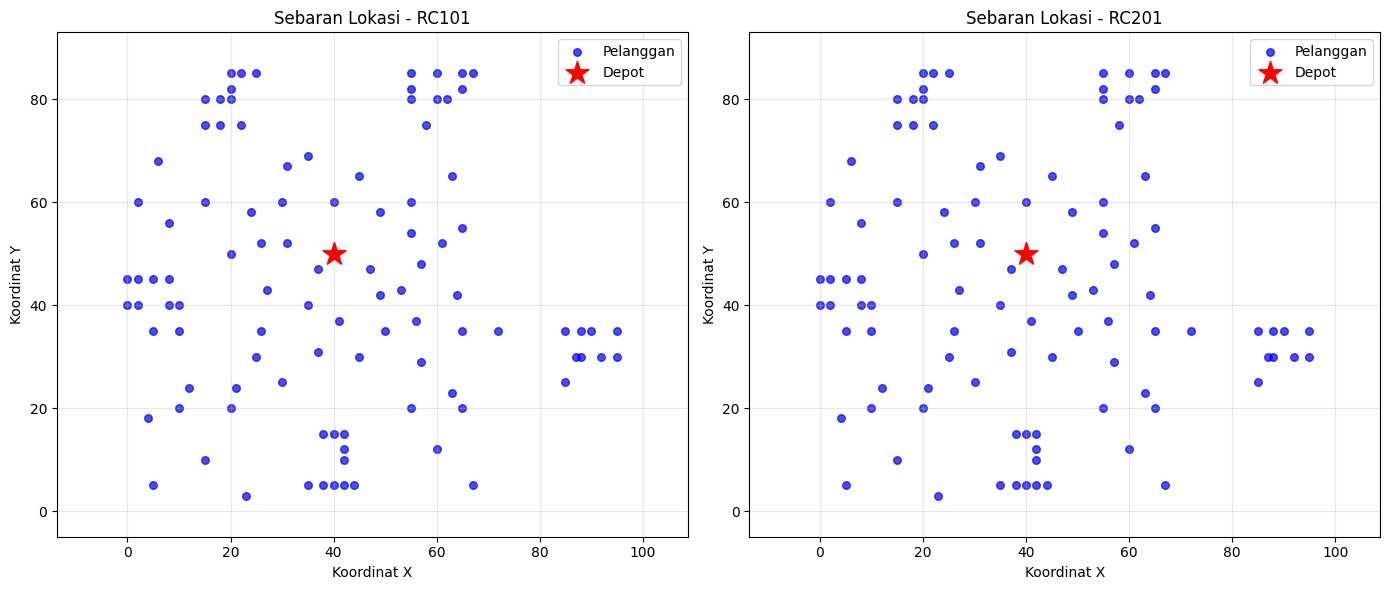

In [10]:
# ================================================================
# 3.2. Scatter Plot Lokasi Depot & Pelanggan (OVERLAY)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (inst_name, spec) in enumerate(EDA_INSTANCE_SPECS.items()):
    p: ProblemData = spec["problem"]
    coords = p.coords
    depot_idx = p.depot_index
    cust_idx = p.customer_indices

    ax = axes[idx]
    ax.scatter(
        coords[cust_idx, 0],
        coords[cust_idx, 1],
        s=30,
        alpha=0.7,
        label="Pelanggan",
        color="blue"
    )
    ax.scatter(
        coords[depot_idx, 0],
        coords[depot_idx, 1],
        marker="*",
        s=300,
        color="red",
        label="Depot",
        zorder=5
    )
    ax.set_title(f"Sebaran Lokasi - {inst_name}")
    ax.set_xlabel("Koordinat X")
    ax.set_ylabel("Koordinat Y")
    ax.axis("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


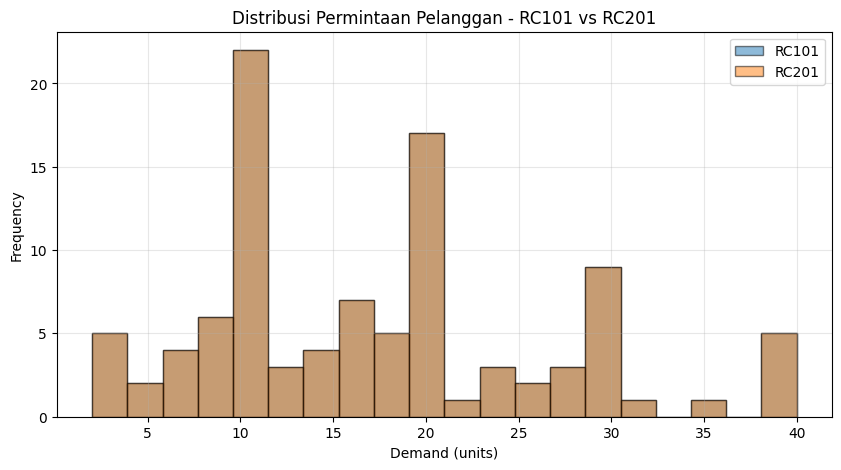

In [11]:
# ================================================================
# Distribusi Permintaan Pelanggan (OVERLAY)
# ================================================================

plt.figure(figsize=(10, 5))
for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    demand_cust = p.demand_units[p.customer_indices]

    plt.hist(demand_cust, bins=20, edgecolor="black", alpha=0.5, label=inst_name)

plt.title("Distribusi Permintaan Pelanggan - RC101 vs RC201")
plt.xlabel("Demand (units)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

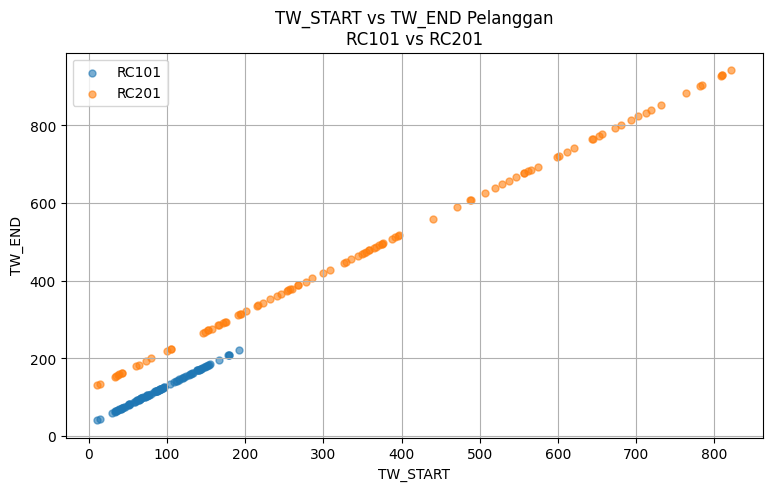

In [12]:
# ============================================
# Scatter TW_START vs TW_END (Pelanggan) - RC101 vs RC201
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    cust_idx = p.customer_indices

    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust   = p.tw_end[cust_idx]

    plt.scatter(
        tw_start_cust,
        tw_end_cust,
        s=25,
        alpha=0.6,
        label=inst_name
    )

plt.title("TW_START vs TW_END Pelanggan\nRC101 vs RC201")
plt.xlabel("TW_START")
plt.ylabel("TW_END")
plt.grid(True)
plt.legend()
plt.show()


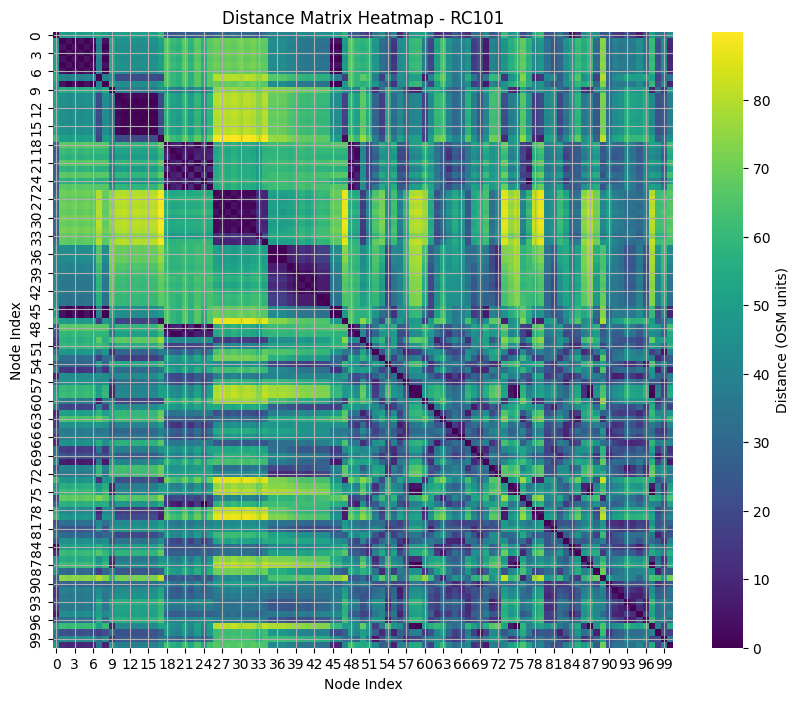

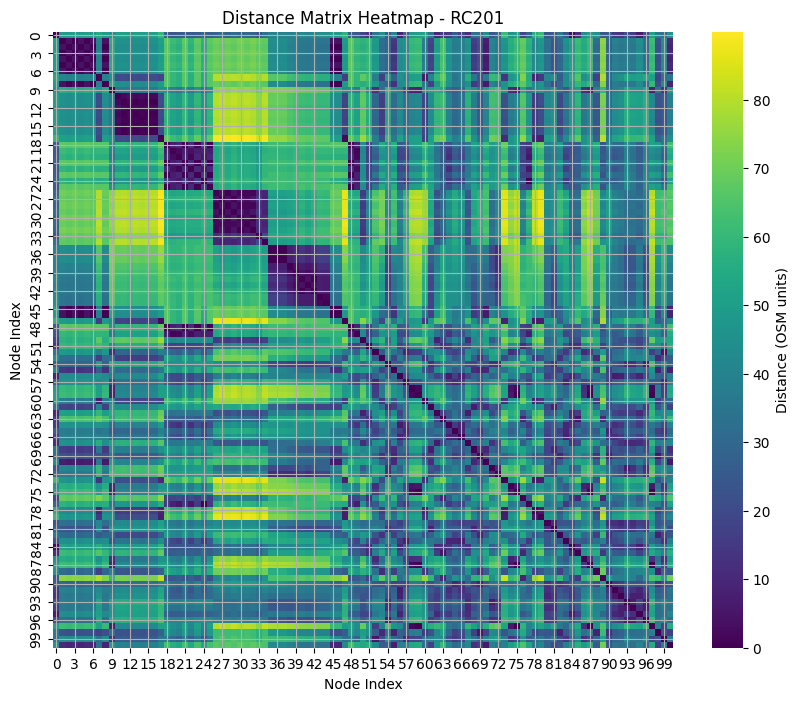

In [13]:
# ================================================================
# Heatmap Matriks Jarak (Struktur Spasial)
# ================================================================

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]

    plt.figure(figsize=(10, 8))
    sns.heatmap(p.dist_matrix, cmap="viridis", cbar_kws={"label": "Distance (OSM units)"})
    plt.title(f"Distance Matrix Heatmap - {inst_name}")
    plt.xlabel("Node Index")
    plt.ylabel("Node Index")
    plt.show()


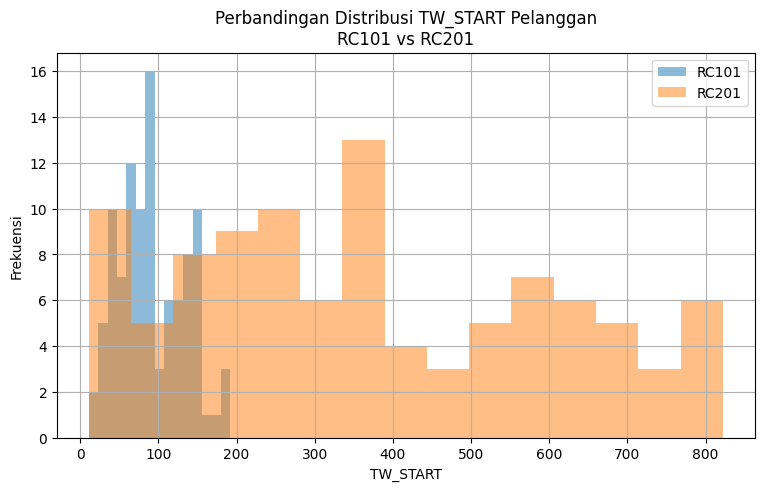

In [14]:
# ============================================
# Perbandingan Distribusi TW_START (RC101 vs RC201)
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p = spec["problem"]
    cust_idx = p.customer_indices
    tw_start = p.tw_start[cust_idx]

    plt.hist(
        tw_start,
        bins=15,
        alpha=0.5,
        label=inst_name
    )

plt.title("Perbandingan Distribusi TW_START Pelanggan\nRC101 vs RC201")
plt.xlabel("TW_START")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()


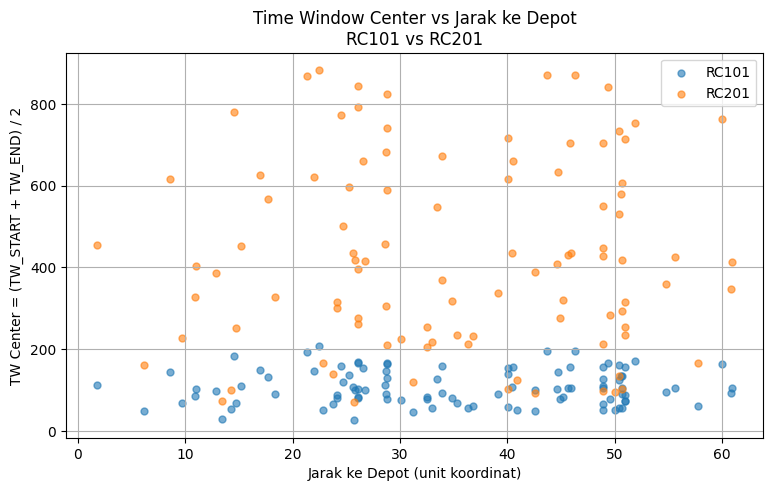

In [15]:
# ============================================
# Time Window Center vs Jarak ke Depot (RC101 vs RC201)
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    depot_idx = p.depot_index
    cust_idx = p.customer_indices

    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust   = p.tw_end[cust_idx]
    tw_center     = 0.5 * (tw_start_cust + tw_end_cust)

    dist_from_depot = p.dist_matrix[depot_idx, cust_idx]

    # Satu scatter per instance, dengan label untuk legenda
    plt.scatter(
        dist_from_depot,
        tw_center,
        s=25,
        alpha=0.6,
        label=inst_name
    )

plt.title("Time Window Center vs Jarak ke Depot\nRC101 vs RC201")
plt.xlabel("Jarak ke Depot (unit koordinat)")
plt.ylabel("TW Center = (TW_START + TW_END) / 2")
plt.grid(True)
plt.legend()
plt.show()


--- Diagnosa Data RC101 ---


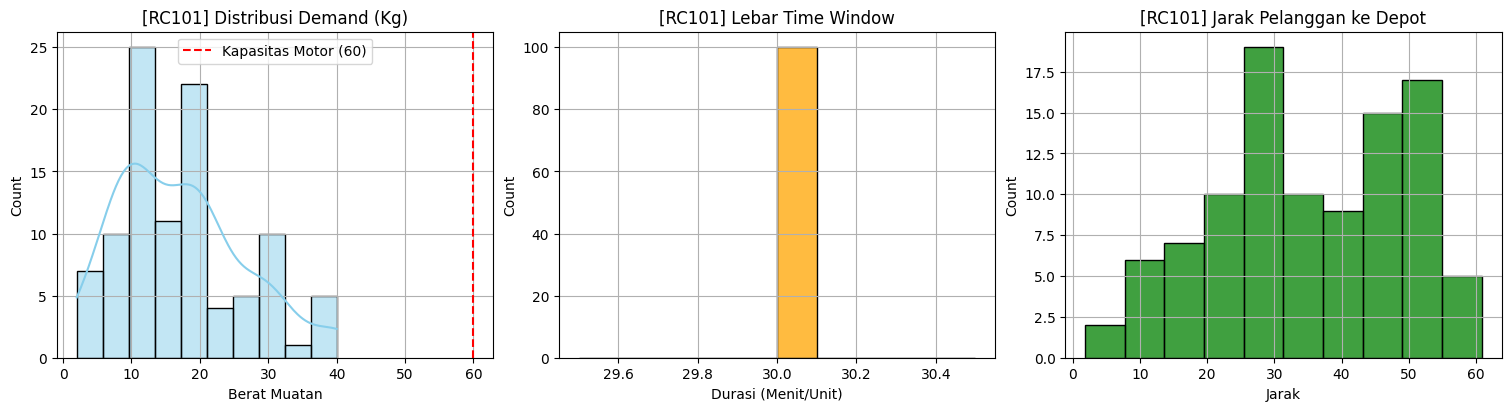


--- Diagnosa Data RC201 ---


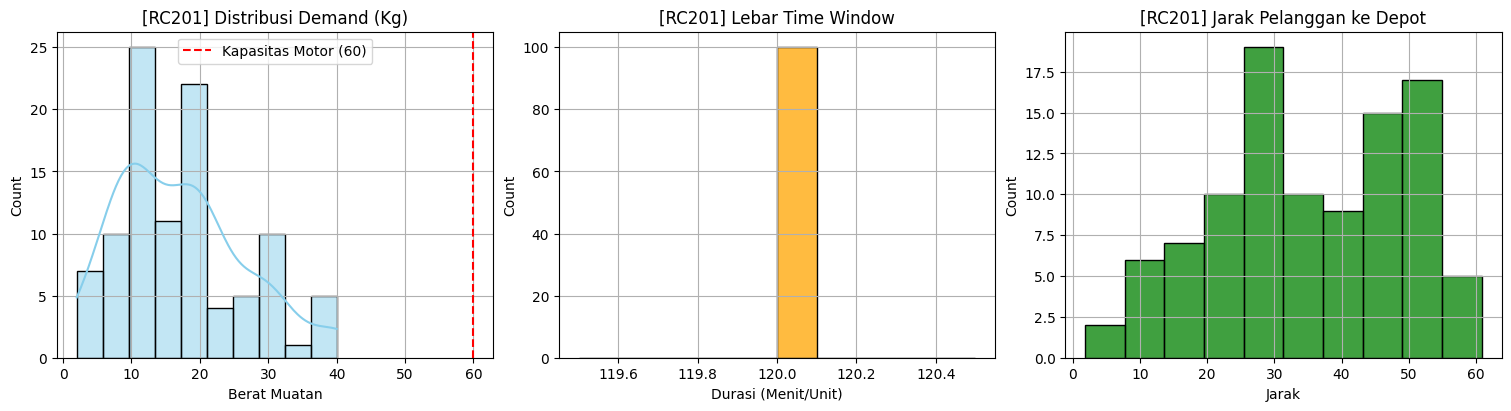


--- Peta Interaktif RC101 (Surakarta) ---


In [16]:
# ==============================================================================
# CELL 8 (FIXED): EXPLORATORY DATA ANALYSIS (EDA) & VISUALISASI PETA
# ==============================================================================

import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec  # <--- INI YANG TADI KURANG

# -----------------------------------------------------------
# 1. FUNGSI VISUALISASI PETA REAL (FOLIUM)
# -----------------------------------------------------------
def visualize_instance_on_real_map(instance_name, core_npz_path):
    """
    Membuat peta interaktif Folium dari data Lat/Lon di file NPZ.
    """
    # Load Lat/Lon dari NPZ
    if not core_npz_path.exists():
        print(f"❌ File NPZ tidak ditemukan: {core_npz_path}")
        return None

    with np.load(core_npz_path) as data:
        latlon = data['latlon']       # [N, 2] (Lat, Lon)
        demand = data['demandunits']  # [N,]
        is_depot = data['isdepot']    # [N,]

    # Ambil koordinat depot untuk sentral peta
    depot_idx = np.where(is_depot)[0][0]
    depot_loc = latlon[depot_idx]

    # Buat Peta Dasar
    m = folium.Map(location=depot_loc, zoom_start=13, tiles='CartoDB positron')

    # Judul
    title_html = f'<h3 align="center" style="font-size:16px"><b>{instance_name} in Surakarta</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    # Plot Pelanggan & Depot
    for i in range(len(latlon)):
        loc = latlon[i]
        d = demand[i]

        if is_depot[i]:
            # Marker Depot (Bintang Merah)
            folium.Marker(
                location=loc,
                popup=folium.Popup(f"<b>DEPOT</b>", max_width=200),
                icon=folium.Icon(color='red', icon='star')
            ).add_to(m)

            # Lingkaran area sekitar depot
            folium.Circle(
                location=loc,
                radius=3000,
                color='red',
                fill=True,
                fill_opacity=0.05
            ).add_to(m)
        else:
            # Marker Pelanggan (Lingkaran Biru)
            radius = 3 + (d / 5.0)

            folium.CircleMarker(
                location=loc,
                radius=radius,
                popup=f"Cust {i}<br>Demand: {d} kg",
                color='blue',
                fill=True,
                fill_color='#3186cc',
                fill_opacity=0.7
            ).add_to(m)

    return m

# -----------------------------------------------------------
# 2. FUNGSI ANALISIS DATA (MATPLOTLIB/SEABORN)
# -----------------------------------------------------------
def plot_instance_diagnostics(problem_data):
    """
    Menampilkan 3 grafik diagnostik: Demand, Time Window, dan Jarak.
    """
    name = problem_data.instance_name
    demands = problem_data.demand_units[problem_data.customer_indices]
    matrix = problem_data.dist_matrix
    depot = problem_data.depot_index

    # Hitung jarak tiap customer ke depot
    dist_to_depot = matrix[depot, problem_data.customer_indices]

    fig = plt.figure(figsize=(15, 4), constrained_layout=True)
    
    # GridSpec sekarang sudah dikenali
    gs = GridSpec(1, 3, figure=fig)

    # A. Distribusi Demand
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(demands, bins=10, kde=True, color='skyblue', ax=ax1)
    ax1.set_title(f"[{name}] Distribusi Demand (Kg)")
    ax1.set_xlabel("Berat Muatan")
    ax1.axvline(60, color='red', linestyle='--', label='Kapasitas Motor (60)')
    ax1.legend()

    # B. Time Window Width
    ax2 = fig.add_subplot(gs[0, 1])
    tw_width = problem_data.tw_end - problem_data.tw_start
    tw_cust = tw_width[problem_data.customer_indices]
    sns.histplot(tw_cust, bins=10, color='orange', ax=ax2)
    ax2.set_title(f"[{name}] Lebar Time Window")
    ax2.set_xlabel("Durasi (Menit/Unit)")

    # C. Jarak dari Depot
    ax3 = fig.add_subplot(gs[0, 2])
    sns.histplot(dist_to_depot, bins=10, color='green', ax=ax3)
    ax3.set_title(f"[{name}] Jarak Pelanggan ke Depot")
    ax3.set_xlabel("Jarak")

    plt.show()

# ===========================================================
# EKSEKUSI VISUALISASI
# ===========================================================

# Pastikan variable problems sudah terisi (dari Cell Load Data)
if 'problems' in globals():
    # 1. Tampilkan Grafik Diagnostik
    print("--- Diagnosa Data RC101 ---")
    plot_instance_diagnostics(problems["RC101"])

    print("\n--- Diagnosa Data RC201 ---")
    plot_instance_diagnostics(problems["RC201"])

    # 2. Tampilkan Peta Interaktif
    print("\n--- Peta Interaktif RC101 (Surakarta) ---")
    map_rc101 = visualize_instance_on_real_map("RC101", CORERC101NPZ)
    
    # Tampilkan peta di output cell
    display(map_rc101)
else:
    print("⚠️ Warning: Variabel 'problems' belum ada. Harap jalankan Cell Load Data dulu.")

### Cell 9: Model Evaluasi Rute & Solusi (CORE LOGIC)

In [17]:
# ==============================================================================
# CELL 9: MODEL EVALUASI RUTE & SOLUSI (CORE LOGIC)
# ==============================================================================

from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

# ================================================================
# Struktur Hasil Evaluasi Rute & Solusi
# ================================================================

@dataclass
class RouteCostBreakdown:
    """
    Ringkasan biaya & emisi untuk satu rute (satu kendaraan).
    """
    vehicle_type_name: str
    vehicle_type_index: int

    # ukuran dasar rute
    n_customers: int
    total_demand: float

    # waktu & jarak
    distance: float
    moving_time: float
    idle_time: float
    route_duration: float

    # pelanggaran kendala
    capacity_violation: float
    tw_violation: float
    duration_violation: float

    # komponen emisi
    moving_emission: float
    idle_emission: float

    # biaya Green-lite (terpenalti)
    green_cost: float
    penalized_cost: float

    # metrik tambahan
    n_late_customers: int = 0


@dataclass
class SolutionCostBreakdown:
    """
    Ringkasan biaya & emisi untuk satu solusi lengkap (kumpulan rute).
    """
    n_routes: int
    routes_per_type: Dict[str, int]

    total_distance: float
    total_moving_time: float
    total_idle_time: float
    total_route_duration: float

    total_demand: float
    total_capacity_violation: float
    total_tw_violation: float
    total_duration_violation: float

    total_moving_emission: float
    total_idle_emission: float

    green_cost: float        # Biaya lingkungan murni
    penalized_cost: float    # Biaya dengan penalti (untuk optimasi)

    # Kunci leksikografis: (Jumlah Rute, Biaya Terpenalti)
    lexicographic_key: Tuple[int, float]

    # Detil per rute
    route_costs: List[RouteCostBreakdown]

    # Metrik performa layanan
    total_customers: int = 0
    total_late_customers: int = 0
    on_time_ratio: float = 0.0


# ================================================================
# Evaluasi Satu Rute (Green-lite + Penalti)
# ================================================================

def evaluate_route_green_cost(
    problem: ProblemData,
    route_customers: List[int],
    vehicle_type: VehicleTypeConfig,
    objective_cfg: Optional[ObjectiveConfig] = None,
    penalty_cfg: Optional[PenaltyConfig] = None,
) -> RouteCostBreakdown:
    """
    Menghitung biaya & emisi sebuah rute untuk satu tipe kendaraan.
    Kompatibel dengan mode Solomon-Unit maupun Map-Real (tergantung isi ProblemData).
    """
    if objective_cfg is None:
        objective_cfg = problem.objective_config
    if penalty_cfg is None:
        penalty_cfg = problem.penalty_config

    if len(route_customers) == 0:
        return RouteCostBreakdown(
            vehicle_type_name=vehicle_type.name,
            vehicle_type_index=-1,
            n_customers=0, total_demand=0.0, distance=0.0,
            moving_time=0.0, idle_time=0.0, route_duration=0.0,
            capacity_violation=0.0, tw_violation=0.0, duration_violation=0.0,
            moving_emission=0.0, idle_emission=0.0,
            green_cost=0.0, penalized_cost=0.0, n_late_customers=0,
        )

    depot = problem.depot_index
    n_cust = len(route_customers)

    # Rute Lengkap: Depot -> C1 -> C2 -> ... -> Depot
    seq = [depot] + list(route_customers) + [depot]

    time = 0.0          # Waktu saat ini
    distance = 0.0      # Total jarak
    moving_time = 0.0   # Total waktu bergerak
    idle_time = 0.0     # Total waktu diam (waiting + service)
    tw_violation = 0.0  # Total keterlambatan

    load = 0.0
    max_load = 0.0
    n_late_customers = 0

    # Safety: hindari pembagian dengan nol
    eff_speed = max(float(vehicle_type.speed_factor), 1e-3)

    for i in range(len(seq) - 1):
        idx_from = seq[i]
        idx_to = seq[i+1]

        # Ambil data jarak & waktu dasar dari matriks ProblemData
        d_ij = float(problem.dist_matrix[idx_from, idx_to])
        t_base = float(problem.travel_time_matrix[idx_from, idx_to])

        # Waktu tempuh efektif (sesuai jenis kendaraan)
        t_ij = t_base / eff_speed

        distance += d_ij
        moving_time += t_ij
        time += t_ij

        # Jika tiba di pelanggan (bukan depot akhir)
        if not problem.is_depot[idx_to]:
            # 1. Update Muatan
            load += float(problem.demand_units[idx_to])
            max_load = max(max_load, load)

            # 2. Cek Time Window
            tw_start_j = float(problem.tw_start[idx_to])
            tw_end_j = float(problem.tw_end[idx_to])

            # Case A: Tiba Terlalu Awal (Waiting)
            if time < tw_start_j:
                wait = tw_start_j - time
                idle_time += wait
                time = tw_start_j # Kendaraan menunggu sampai buka

            # Case B: Tiba Terlambat (Time Warp)
            elif time > tw_end_j:
                late = time - tw_end_j
                tw_violation += late
                n_late_customers += 1
                # Di VRP klasik, waktu tidak dimundurkan, penalti dicatat

            # 3. Waktu Layanan (Service)
            service_j = float(problem.service_time[idx_to])
            time += service_j

            # Opsi: Hitung service time sebagai emisi idle?
            if objective_cfg.include_service_in_idle:
                idle_time += service_j

    route_duration = time

    # --- Hitung Pelanggaran ---
    capacity_violation = max(0.0, max_load - vehicle_type.capacity_units)

    duration_violation = 0.0
    if vehicle_type.max_route_duration is not None:
        duration_violation = max(0.0, route_duration - vehicle_type.max_route_duration)

    # --- Hitung Emisi ---
    moving_emission = distance * vehicle_type.ef_km
    idle_emission = idle_time * vehicle_type.ef_idle_per_min

    # --- Hitung Biaya Green-Lite (Objektif Asli) ---
    w_d, w_move, w_idle = objective_cfg.as_tuple()
    green_cost = (
        w_d * distance +
        w_move * moving_emission +
        w_idle * idle_emission
    )

    # --- Hitung Biaya Terpenalti (Objektif Optimasi) ---
    penalized_cost = (
        green_cost +
        penalty_cfg.lambda_load * capacity_violation +
        penalty_cfg.lambda_tw * tw_violation +
        penalty_cfg.lambda_duration * duration_violation
    )

    return RouteCostBreakdown(
        vehicle_type_name=vehicle_type.name,
        vehicle_type_index=-1,
        n_customers=n_cust,
        total_demand=float(max_load),
        distance=distance,
        moving_time=moving_time,
        idle_time=idle_time,
        route_duration=route_duration,
        capacity_violation=capacity_violation,
        tw_violation=tw_violation,
        duration_violation=duration_violation,
        moving_emission=moving_emission,
        idle_emission=idle_emission,
        green_cost=green_cost,
        penalized_cost=penalized_cost,
        n_late_customers=n_late_customers,
    )

### CELL 10: EVALUASI SOLUSI, METRIK, DAN UNIT TESTING

In [18]:
# ==============================================================================
# CELL 10: EVALUASI SOLUSI, METRIK, DAN UNIT TESTING
# ==============================================================================

from typing import List, Tuple, Dict, Optional
from collections import defaultdict

# ================================================================
# 4.3. Evaluasi Solusi Lengkap (Missing Function)
# ================================================================

def evaluate_solution_green_cost(
    problem: ProblemData,
    routes: List[Tuple[int, List[int]]],  # List of (vehicle_type_idx, [customer_ids])
    objective_cfg: Optional[ObjectiveConfig] = None,
    penalty_cfg: Optional[PenaltyConfig] = None,
) -> SolutionCostBreakdown:
    """
    Mengevaluasi satu solusi lengkap (kumpulan rute).
    Mengagregasi biaya dari setiap rute individu.
    """
    if objective_cfg is None:
        objective_cfg = problem.objective_config
    if penalty_cfg is None:
        penalty_cfg = problem.penalty_config

    # Inisialisasi Akumulator
    total_distance = 0.0
    total_moving_time = 0.0
    total_idle_time = 0.0
    total_route_duration = 0.0

    total_demand = 0.0
    total_cap_violation = 0.0
    total_tw_violation = 0.0
    total_dur_violation = 0.0

    total_moving_emission = 0.0
    total_idle_emission = 0.0

    green_cost = 0.0
    penalized_cost = 0.0

    routes_per_type = defaultdict(int)
    route_costs = []

    total_late_customers = 0
    total_customers_served = 0

    # Iterasi setiap rute dalam solusi
    for v_type_idx, route_custs in routes:
        # Ambil konfigurasi kendaraan berdasarkan index
        v_type = problem.fleet_config.vehicle_types[v_type_idx]
        routes_per_type[v_type.name] += 1

        # Evaluasi Rute Individu
        rc = evaluate_route_green_cost(
            problem, route_custs, v_type, objective_cfg, penalty_cfg
        )
        route_costs.append(rc)

        # Agregasi Metrik
        total_distance += rc.distance
        total_moving_time += rc.moving_time
        total_idle_time += rc.idle_time
        total_route_duration += rc.route_duration

        total_demand += rc.total_demand
        total_cap_violation += rc.capacity_violation
        total_tw_violation += rc.tw_violation
        total_dur_violation += rc.duration_violation

        total_moving_emission += rc.moving_emission
        total_idle_emission += rc.idle_emission

        green_cost += rc.green_cost
        penalized_cost += rc.penalized_cost

        total_late_customers += rc.n_late_customers
        total_customers_served += rc.n_customers

    # Hitung Rasio On-Time
    on_time_ratio = 1.0
    if total_customers_served > 0:
        on_time_ratio = 1.0 - (total_late_customers / total_customers_served)

    n_routes = len(routes)

    # Kunci Leksikografis untuk Sorting/Seleksi HGS:
    # 1. Minimalkan Jumlah Kendaraan (Tier-1)
    # 2. Minimalkan Biaya Terpenalti (Tier-2)
    lex_key = (n_routes, penalized_cost)

    return SolutionCostBreakdown(
        n_routes=n_routes,
        routes_per_type=dict(routes_per_type),
        total_distance=total_distance,
        total_moving_time=total_moving_time,
        total_idle_time=total_idle_time,
        total_route_duration=total_route_duration,
        total_demand=total_demand,
        total_capacity_violation=total_cap_violation,
        total_tw_violation=total_tw_violation,
        total_duration_violation=total_dur_violation,
        total_moving_emission=total_moving_emission,
        total_idle_emission=total_idle_emission,
        green_cost=green_cost,
        penalized_cost=penalized_cost,
        lexicographic_key=lex_key,
        route_costs=route_costs,
        total_customers=total_customers_served,
        total_late_customers=total_late_customers,
        on_time_ratio=on_time_ratio
    )

# ================================================================
# 4.4. Helper: Ekstraksi Metrik Ringkas
# ================================================================

def compute_solution_metrics(
    problem: ProblemData,
    solution_cost: SolutionCostBreakdown,
) -> Dict[str, float]:
    """
    Mengekstrak metrik ringkas dari SolutionCostBreakdown untuk logging & analisis.
    """
    E_total = solution_cost.total_moving_emission + solution_cost.total_idle_emission

    # Utilisasi kapasitas rata-rata per rute
    avg_load = 0.0
    avg_cap = 0.0
    if solution_cost.n_routes > 0:
        total_cap = sum(
            rc.total_demand for rc in solution_cost.route_costs
        )
        avg_load = total_cap / solution_cost.n_routes

        # kapasitas rata-rata kendaraan yang digunakan
        cap_sum = 0.0
        for rc in solution_cost.route_costs:
            vtype_name = rc.vehicle_type_name
            for vt in problem.fleet_config.vehicle_types:
                if vt.name == vtype_name:
                    cap_sum += vt.capacity_units
                    break
        avg_cap = cap_sum / solution_cost.n_routes if solution_cost.n_routes > 0 else 0.0

    avg_utilization = (avg_load / avg_cap) if avg_cap > 0 else 0.0

    return {
        "E_total": E_total,
        "avg_distance_per_route": (
            solution_cost.total_distance / solution_cost.n_routes
            if solution_cost.n_routes > 0 else 0.0
        ),
        "avg_load": avg_load,
        "avg_utilization": avg_utilization,
        "total_customers": float(solution_cost.total_customers),
        "total_late_customers": float(solution_cost.total_late_customers),
        "on_time_ratio": solution_cost.on_time_ratio,
    }


# ================================================================
# 4.5. Tes Cepat: Evaluasi Rute & Solusi Contoh
# ================================================================

print("="*70)
print("Tes Model Emisi & Fungsi Biaya Green-Lite")
print("="*70)

# Pilih instance untuk tes (RC101)
# Pastikan 'problems' dictionary sudah ada dari Cell 7
if 'problems' in globals():
    test_problem = problems["RC101"]
    depot_idx = test_problem.depot_index

    # Buat rute contoh: depot -> [1, 2, 3] -> depot
    route_customers = [1, 2, 3]
    vtype = test_problem.fleet_config.vehicle_types[0]  # tipe pertama (motorcycle)

    route_cost = evaluate_route_green_cost(
        test_problem, route_customers, vtype
    )

    print(f"\nRute contoh: depot -> {route_customers} -> depot")
    print(f"Tipe kendaraan: {vtype.name}")
    print(f"  - Distance: {route_cost.distance:.2f}")
    print(f"  - Moving time: {route_cost.moving_time:.2f}")
    print(f"  - Idle time: {route_cost.idle_time:.2f}")
    print(f"  - Route duration: {route_cost.route_duration:.2f}")
    print(f"  - Moving emission: {route_cost.moving_emission:.2f}")
    print(f"  - Idle emission: {route_cost.idle_emission:.2f}")
    print(f"  - Green cost: {route_cost.green_cost:.2f}")
    print(f"  - Penalized cost: {route_cost.penalized_cost:.2f}")
    print(f"  - TW violation: {route_cost.tw_violation:.2f}")
    print(f"  - Capacity violation: {route_cost.capacity_violation:.2f}")

    # Buat solusi contoh dengan 2 rute
    # (indeks kendaraan 0=motor, 1=van - asumsikan urutan di JSON benar)
    routes_repr = [
        (0, [1, 2, 3]),    # motorcycle
        (1, [4, 5, 6, 7])  # van
    ]

    solution_cost = evaluate_solution_green_cost(test_problem, routes_repr)

    print(f"\nSolusi contoh: {len(routes_repr)} rute")
    print(f"  - Routes per type: {solution_cost.routes_per_type}")
    print(f"  - Total distance: {solution_cost.total_distance:.2f}")
    print(f"  - Total moving emission: {solution_cost.total_moving_emission:.2f}")
    print(f"  - Total idle emission: {solution_cost.total_idle_emission:.2f}")
    print(f"  - Green cost: {solution_cost.green_cost:.2f}")
    print(f"  - Penalized cost: {solution_cost.penalized_cost:.2f}")
    print(f"  - Lexicographic key: {solution_cost.lexicographic_key}")
    print(f"  - On-time ratio: {solution_cost.on_time_ratio:.2%}")
else:
    print("⚠️ Variable 'problems' tidak ditemukan. Jalankan Cell 7 terlebih dahulu.")

print("\n" + "="*70)
print("✓ Bagian 4 (Model Emisi & Fungsi Biaya Green-Lite) selesai!")
print("="*70)

Tes Model Emisi & Fungsi Biaya Green-Lite

Rute contoh: depot -> [1, 2, 3] -> depot
Tipe kendaraan: motorcycle
  - Distance: 108.71
  - Moving time: 98.83
  - Idle time: 129.15
  - Route duration: 227.99
  - Moving emission: 10.87
  - Idle emission: 129.15
  - Green cost: 124.89
  - Penalized cost: 11295.78
  - TW violation: 111.71
  - Capacity violation: 0.00

Solusi contoh: 2 rute
  - Routes per type: {'motorcycle': 1, 'van': 1}
  - Total distance: 259.49
  - Total moving emission: 56.11
  - Total idle emission: 261.29
  - Green cost: 302.45
  - Penalized cost: 35167.04
  - Lexicographic key: (2, 35167.035875470276)
  - On-time ratio: 28.57%

✓ Bagian 4 (Model Emisi & Fungsi Biaya Green-Lite) selesai!


### CELL 11: SPLIT ALGORITHM (BEST VEHICLE SELECTOR)

In [19]:
# ==============================================================================
# CELL 11: SPLIT ALGORITHM (BEST VEHICLE SELECTOR)
# ==============================================================================

# ================================================================
# 5.1. Helper: Best Vehicle Selector (Clean Version)
# ================================================================

def best_vehicle_for_segment(
    problem: ProblemData,
    segment_customers: List[int],
) -> Tuple[int, RouteCostBreakdown]:
    """
    Memilih tipe kendaraan TERBAIK untuk segmen pelanggan tertentu.

    Logika:
    Kita evaluasi segmen ini menggunakan SEMUA tipe kendaraan yang tersedia.
    Pemenangnya adalah kendaraan dengan 'penalized_cost' terendah.

    Kenapa tidak pakai diskon manual?
    Karena fungsi biaya kita sudah mencakup:
    1. Fixed Cost (jika ada di JSON) -> Menghukum penggunaan banyak kendaraan kecil
    2. Emission Cost -> Truk lebih polusi per km, tapi motor butuh banyak trip.
       Trade-off ini sudah terhitung otomatis di 'green_cost'.
    """
    fleet_types = problem.fleet_config.vehicle_types

    best_vidx = -1
    best_rc = None
    min_cost = float('inf')

    # Cek setiap tipe kendaraan
    for vidx, vtype in enumerate(fleet_types):
        # Hitung biaya rute ini jika dilayani oleh kendaraan vtype
        rc = evaluate_route_green_cost(
            problem=problem,
            route_customers=segment_customers,
            vehicle_type=vtype,
        )

        # Biaya penentu adalah penalized_cost
        # (sudah termasuk pelanggaran kapasitas/TW dan biaya emisi)
        cost = rc.penalized_cost

        # Tambahkan Fixed Cost kendaraan (jika didefinisikan di JSON)
        # Ini penting agar algoritma tidak spamming motor jika tidak perlu
        cost += vtype.fixed_cost

        # Update pemenang
        if cost < min_cost:
            min_cost = cost
            best_vidx = vidx
            best_rc = rc

    if best_rc is None:
        raise RuntimeError(f"Gagal mengevaluasi segmen {segment_customers}")

    return best_vidx, best_rc

### CELL 12: OPTIMAL SPLIT ALGORITHM (BELLMAN-FORD) - MENGGANTIKAN GREEDY

In [20]:
# ==============================================================================
# CELL 12: OPTIMAL SPLIT ALGORITHM (BELLMAN-FORD) - MENGGANTIKAN GREEDY
# ==============================================================================

# ================================================================
# 5.2. Split Decoder: Optimal Bellman-Ford (Shortest Path on DAG)
# ================================================================

def split_giant_tour_optimal(
    problem: ProblemData,
    giant_tour: List[int],
) -> Tuple[List[Tuple[int, List[int]]], SolutionCostBreakdown]:
    """
    Memecah Giant Tour menjadi rute-rute kendaraan menggunakan algoritma
    Shortest Path (Bellman-Ford logic) pada graf Directed Acyclic Graph (DAG).

    Ini menjamin pembagian rute yang OPTIMAL berdasarkan urutan giant_tour yang diberikan,
    tanpa perlu aturan manual "minimal 3 pelanggan" atau "diskon manual".
    Algoritma akan menemukan sendiri apakah lebih murah pakai 1 Truk atau 3 Motor.
    """
    n_tour = len(giant_tour)
    if n_tour == 0:
        empty_routes: List[Tuple[int, List[int]]] = []
        return empty_routes, evaluate_solution_green_cost(problem, empty_routes)

    # V[i] = biaya termurah untuk melayani pelanggan giant_tour[i:] (suffix)
    # Kita bangun dari belakang ke depan (atau depan ke belakang, sama saja).
    # Di sini kita pakai forward (V[i] biaya termurah dari 0 sampai i).

    # V[i] = Cost termurah untuk melayani pelanggan pertama hingga ke-i
    V = [float('inf')] * (n_tour + 1)
    V[0] = 0.0

    # Predecessor untuk rekonstruksi rute: P[i] = (index_start_node, vehicle_idx)
    P = {}

    # --- KONFIGURASI BATCHING UNTUK EFISIENSI ---
    # Kita tidak perlu mengecek rute sepanjang 100 pelanggan jika kapasitas motor cuma 5.
    # Batasi panjang segmen maksimum untuk mempercepat.
    MAX_SEGMENT_LEN = 25  # Cukup besar untuk Truk

    for i in range(n_tour):
        # Jika V[i] inf, berarti node ini tidak terjangkau (should not happen)
        if V[i] == float('inf'):
            continue

        # Coba buat rute baru mulai dari pelanggan ke-(i+1) sampai ke-j
        # Pelanggan giant_tour[i] adalah pelanggan pertama di rute baru ini

        current_load = 0.0
        current_dist = 0.0

        # Iterasi j dari i+1 sampai batas maksimum
        for j in range(i + 1, min(i + MAX_SEGMENT_LEN, n_tour) + 1):
            segment = giant_tour[i:j] # Pelanggan indeks i s.d j-1

            # Cari kendaraan terbaik untuk segmen ini
            vidx, best_rc = best_vehicle_for_segment(problem, segment)

            cost_segment = best_rc.penalized_cost

            # Tambahkan Fixed Cost kendaraan di sini (agar algoritma sadar biaya sewa)
            vtype = problem.fleet_config.vehicle_types[vidx]
            cost_segment += vtype.fixed_cost

            # Relaksasi Bellman-Ford
            if V[i] + cost_segment < V[j]:
                V[j] = V[i] + cost_segment
                P[j] = (i, vidx) # Rute berakhir di j, mulai dari i, pakai kendaraan vidx

    # --- REKONSTRUKSI RUTE DARI P ---
    routes_repr = []
    curr = n_tour

    while curr > 0:
        start_idx, vidx = P[curr]
        segment = giant_tour[start_idx:curr]
        routes_repr.append((vidx, segment))
        curr = start_idx

    # Karena kita mundur dari n_tour ke 0, urutan rute jadi terbalik
    routes_repr.reverse()

    # Evaluasi ulang solusi akhir untuk mendapatkan breakdown lengkap
    sol_cost = evaluate_solution_green_cost(problem, routes_repr)

    return routes_repr, sol_cost

### CELL 13: SPLIT REFINEMENT (LOCAL SEARCH ON BOUNDARIES)

In [21]:
# ==============================================================================
# CELL 13: SPLIT REFINEMENT (LOCAL SEARCH ON BOUNDARIES)
# ==============================================================================

# ================================================================
# 5.3. Split Refinement Boundary
# ================================================================

def refine_split_boundaries(
    problem: ProblemData,
    routes_repr: List[Tuple[int, List[int]]],
    max_shift: int = 1,
    max_passes: int = 1,
) -> Tuple[List[Tuple[int, List[int]]], SolutionCostBreakdown]:
    """
    Melakukan perbaikan lokal di perbatasan antar rute (Boundary Local Search).
    Mencoba memindahkan pelanggan di ujung rute i ke rute i+1, atau sebaliknya.
    """

    # Copy deep enough
    best_routes = [(vidx, list(seq)) for (vidx, seq) in routes_repr]

    # Evaluasi solusi awal
    best_cost = evaluate_solution_green_cost(problem, best_routes)
    best_lex = best_cost.lexicographic_key

    if len(best_routes) <= 1 or max_shift <= 0 or max_passes <= 0:
        return best_routes, best_cost

    improved = True
    passes_done = 0

    while improved and passes_done < max_passes:
        improved = False
        passes_done += 1

        # Iterasi setiap boundary antar rute
        # Karena jumlah rute bisa berubah (kalau ada rute kosong dihapus),
        # kita pakai while index manual
        boundary_idx = 0

        while boundary_idx < len(best_routes) - 1:
            # Rute Kiri (i) dan Kanan (i+1)
            (left_v_orig, left_seq_orig) = best_routes[boundary_idx]
            (right_v_orig, right_seq_orig) = best_routes[boundary_idx + 1]

            left_seq = list(left_seq_orig)
            right_seq = list(right_seq_orig)

            # Skip jika salah satu kosong (safety)
            if len(left_seq) == 0 or len(right_seq) == 0:
                boundary_idx += 1
                continue

            candidate_found = False

            # --- SKENARIO A: Geser dari KIRI ke KANAN (Shift Right) ---
            # Coba pindahkan 1..max_shift pelanggan
            for s in range(1, min(max_shift + 1, len(left_seq) + 1)):
                moved = left_seq[-s:]      # Ambil ekor kiri
                new_left = left_seq[:-s]   # Sisa kiri
                new_right = moved + right_seq # Tempel ke kepala kanan

                # Rekonstruksi Solusi Kandidat
                cand_routes = []
                for idx, (v_orig, seq_orig) in enumerate(best_routes):
                    if idx == boundary_idx:
                        if len(new_left) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_left)
                            cand_routes.append((v_new, new_left))
                    elif idx == boundary_idx + 1:
                        if len(new_right) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_right)
                            cand_routes.append((v_new, new_right))
                    else:
                        cand_routes.append((v_orig, list(seq_orig)))

                # Evaluasi
                cand_cost = evaluate_solution_green_cost(problem, cand_routes)
                cand_lex = cand_cost.lexicographic_key

                # Jika membaik secara leksikografis
                if cand_lex < best_lex:
                    best_routes = cand_routes
                    best_cost = cand_cost
                    best_lex = cand_lex
                    candidate_found = True
                    improved = True
                    break # Ambil perbaikan pertama (First Improvement)

            if candidate_found:
                # Boundary mungkin bergeser/hilang, restart loop boundary atau adjust index
                # Simplifikasi: karena struktur list berubah, kita bisa restart loop boundary
                # atau cukup skip ke boundary berikutnya (tapi hati-hati index).
                # Di sini kita 'continue' tapi boundary_idx tidak ditambah -> cek boundary baru di posisi sama
                # (karena best_routes sudah berubah di posisi boundary_idx)
                continue

            # --- SKENARIO B: Geser dari KANAN ke KIRI (Shift Left) ---
            for s in range(1, min(max_shift + 1, len(right_seq) + 1)):
                moved = right_seq[:s]      # Ambil kepala kanan
                new_left = left_seq + moved # Tempel ke ekor kiri
                new_right = right_seq[s:]  # Sisa kanan

                cand_routes = []
                for idx, (v_orig, seq_orig) in enumerate(best_routes):
                    if idx == boundary_idx:
                        if len(new_left) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_left)
                            cand_routes.append((v_new, new_left))
                    elif idx == boundary_idx + 1:
                        if len(new_right) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_right)
                            cand_routes.append((v_new, new_right))
                    else:
                        cand_routes.append((v_orig, list(seq_orig)))

                cand_cost = evaluate_solution_green_cost(problem, cand_routes)
                cand_lex = cand_cost.lexicographic_key

                if cand_lex < best_lex:
                    best_routes = cand_routes
                    best_cost = cand_cost
                    best_lex = cand_lex
                    candidate_found = True
                    improved = True
                    break

            if candidate_found:
                continue # Cek boundary ini lagi (karena isinya sudah berubah)

            # Jika tidak ada perbaikan di boundary ini, lanjut ke boundary sebelah
            boundary_idx += 1

    return best_routes, best_cost

### CELL 14: UNIT TEST SPLIT ALGORITHM (OPTIMAL BELLMAN-FORD)

In [22]:
# ==============================================================================
# CELL 14: UNIT TEST SPLIT ALGORITHM (OPTIMAL BELLMAN-FORD)
# ==============================================================================

# ================================================================
# 5.4. Tes Cepat: Split Decoder pada Giant Tour Contoh
# ================================================================

print("="*70)
print("Tes Split Decoder OPTIMAL (Bellman-Ford Logic)")
print("="*70)

# Giant tour contoh: urutan pelanggan 1-10
# (Asumsi pelanggan berdekatan secara geografis di dataset Solomon)
giant_tour_example = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# --- 1. Decode untuk RC101 ---
print("\nInstance: RC101 (Karakteristik: Kapasitas Ketat, TW Sempit)")
print(f"Giant tour: {giant_tour_example}")

# PANGGIL FUNGSI BARU (OPTIMAL)
routes_rc101, sol_rc101 = split_giant_tour_optimal(
    problemrc101,
    giant_tour_example,
)

print(f"\nHasil split: {len(routes_rc101)} rute")
for i, (vtype_idx, route_customers) in enumerate(routes_rc101):
    vtype_name = problemrc101.fleet_config.vehicle_types[vtype_idx].name
    print(f"  Rute {i+1}: {vtype_name} -> {route_customers}")

print(f"\nLexicographic key: {sol_rc101.lexicographic_key}")
print(f"  - K (jumlah rute): {sol_rc101.n_routes}")
print(f"  - Cost (penalized): {sol_rc101.penalized_cost:.2f}")
print(f"  - Green cost: {sol_rc101.green_cost:.2f}")
print(f"  - Total distance: {sol_rc101.total_distance:.2f}")
print(f"  - On-time ratio: {sol_rc101.on_time_ratio:.2%}")

# --- 2. Decode untuk RC201 ---
print("\n" + "-"*70)
print("Instance: RC201 (Karakteristik: Horizon Panjang, Rute Bisa Besar)")
print(f"Giant tour: {giant_tour_example}")

# PANGGIL FUNGSI BARU (OPTIMAL)
routes_rc201, sol_rc201 = split_giant_tour_optimal(
    problemrc201,
    giant_tour_example,
)

print(f"\nHasil split: {len(routes_rc201)} rute")
for i, (vtype_idx, route_customers) in enumerate(routes_rc201):
    vtype_name = problemrc201.fleet_config.vehicle_types[vtype_idx].name
    print(f"  Rute {i+1}: {vtype_name} -> {route_customers}")

print(f"\nLexicographic key: {sol_rc201.lexicographic_key}")
print(f"  - K (jumlah rute): {sol_rc201.n_routes}")
print(f"  - Cost (penalized): {sol_rc201.penalized_cost:.2f}")
print(f"  - Green cost: {sol_rc201.green_cost:.2f}")
print(f"  - Total distance: {sol_rc201.total_distance:.2f}")
print(f"  - On-time ratio: {sol_rc201.on_time_ratio:.2%}")

print("\n" + "="*70)
print("✓ Bagian 5 (Split Decoder OPTIMAL) selesai!")
print("="*70)

Tes Split Decoder OPTIMAL (Bellman-Ford Logic)

Instance: RC101 (Karakteristik: Kapasitas Ketat, TW Sempit)
Giant tour: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Hasil split: 6 rute
  Rute 1: motorcycle -> [1]
  Rute 2: van -> [2, 3, 4]
  Rute 3: motorcycle -> [5, 6]
  Rute 4: motorcycle -> [7]
  Rute 5: motorcycle -> [8]
  Rute 6: motorcycle -> [9, 10]

Lexicographic key: (6, 717.8205020974473)
  - K (jumlah rute): 6
  - Cost (penalized): 717.82
  - Green cost: 717.82
  - Total distance: 649.57
  - On-time ratio: 100.00%

----------------------------------------------------------------------
Instance: RC201 (Karakteristik: Horizon Panjang, Rute Bisa Besar)
Giant tour: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Hasil split: 4 rute
  Rute 1: truck -> [1]
  Rute 2: van -> [2, 3, 4]
  Rute 3: motorcycle -> [5, 6]
  Rute 4: van -> [7, 8, 9, 10]

Lexicographic key: (4, 789.100398202919)
  - K (jumlah rute): 4
  - Cost (penalized): 789.10
  - Green cost: 789.10
  - Total distance: 545.46
  - On-time ratio: 100

## Fase 3: Algoritma Opstimisasi

### CELL 15: REPRESENTASI INDIVIDUAL (CHROMOSOME)

In [23]:
# ==============================================================================
# CELL 15: REPRESENTASI INDIVIDUAL (CHROMOSOME)
# ==============================================================================

# ================================================================
# 6. Representasi Individual & Fitness Lexicographic
# ================================================================

@dataclass
class Individual:
    """
    Representasi individu dalam HGS:
    - Genotype: giant_tour (permutasi pelanggan)
    - Phenotype: routes_repr (hasil decode menjadi rute nyata)
    """
    problem: ProblemData
    giant_tour: List[int]
    routes_repr: Optional[List[Tuple[int, List[int]]]] = None
    solution_cost: Optional[SolutionCostBreakdown] = None

    # Metadata untuk HGS (Diversity & Management)
    age: int = 0          # Umur (generasi)
    n_descendants: int = 0  # Jumlah anak yang dihasilkan

    def __post_init__(self):
        """Auto-evaluate jika belum ada routes_repr."""
        if self.routes_repr is None or self.solution_cost is None:
            self.evaluate()

    def evaluate(self):
        """
        Decode giant_tour menjadi rute dan evaluasi solusi.

        PERBAIKAN PENTING:
        Menggunakan split_giant_tour_optimal (Bellman-Ford)
        bukan greedy_split_giant_tour.
        """
        # Decode giant tour -> routes (Menggunakan Logika Optimal Cell 12)
        self.routes_repr, self.solution_cost = split_giant_tour_optimal(
            self.problem,
            self.giant_tour,
        )

    def ensure_evaluated(self):
        """Pastikan individu sudah dievaluasi."""
        if self.routes_repr is None or self.solution_cost is None:
            self.evaluate()

    @property
    def lexkey(self) -> Tuple:
        """
        Kunci lexicographic untuk perbandingan:
        1. Jumlah Rute (K) -> Minimalkan
        2. Biaya Terpenalti -> Minimalkan
        """
        self.ensure_evaluated()
        return self.solution_cost.lexicographic_key

    @property
    def n_routes(self) -> int:
        """Jumlah rute (K)."""
        self.ensure_evaluated()
        return self.solution_cost.n_routes

    @property
    def penalized_cost(self) -> float:
        """Biaya terpenalti F'_green (fitness value)."""
        self.ensure_evaluated()
        return self.solution_cost.penalized_cost

    @property
    def green_cost(self) -> float:
        """Biaya lingkungan murni F_green (untuk laporan)."""
        self.ensure_evaluated()
        return self.solution_cost.green_cost

    @property
    def is_feasible(self) -> bool:
        """Apakah solusi feasible (semua penalti ~ 0)?"""
        self.ensure_evaluated()
        # Selisih antara penalized dan green cost adalah total penalti
        penalty = self.penalized_cost - self.green_cost
        return penalty < 1e-4

    def clone(self) -> 'Individual':
        """Buat salinan individu (deep copy giant_tour)."""
        return Individual(
            problem=self.problem,
            giant_tour=list(self.giant_tour),
            routes_repr=None, # akan di-evaluate ulang otomatis (clean slate)
            solution_cost=None,
            age=self.age,             # Copy umur
            n_descendants=0,          # Reset descendants (karena ini individu baru)
        )

    def __lt__(self, other: 'Individual') -> bool:
        """
        Operator Less Than (<) untuk sorting.
        Individu A lebih baik dari B jika lexkey A < lexkey B.
        """
        return self.lexkey < other.lexkey


print("="*70)
print("✓ Dataclass Individual (Fixed: Bellman-Ford Split) siap.")
print("="*70)

✓ Dataclass Individual (Fixed: Bellman-Ford Split) siap.


### CELL 16: HELPER INDIVIDUAL FACTORY & UNIT TEST

In [24]:
# ==============================================================================
# CELL 16: HELPER INDIVIDUAL FACTORY & UNIT TEST
# ==============================================================================

import random

# ================================================================
# 6.1. Helper: Buat Individual dari Giant Tour
# ================================================================

def make_individual_from_customers(
    problem: ProblemData,
    customers_perm: List[int],
    evaluate_now: bool = True,
) -> Individual:
    """
    Membuat objek Individual dari permutasi pelanggan (giant tour).
    """
    ind = Individual(
        problem=problem,
        giant_tour=list(customers_perm),
        routes_repr=None,
        solution_cost=None,
    )

    if evaluate_now:
        ind.evaluate()

    return ind


# ================================================================
# 6.2. Tes Cepat: Buat Individual dari Giant Tour Contoh
# ================================================================

print("="*70)
print("Tes Individual (Giant Tour -> Decode -> Fitness)")
print("="*70)

# Pastikan problemrc101 sudah ada (dari Cell 7)
if 'problemrc101' in globals():
    # Giant tour contoh: 100 pelanggan acak
    # Kita gunakan random seed lokal agar hasil konsisten
    rng_test = random.Random(42)

    # Ambil index pelanggan (selain depot)
    cust_indices_rc101 = list(problemrc101.customer_indices)
    rng_test.shuffle(cust_indices_rc101)

    print(f"\nInstance: RC101")
    print(f"Giant tour: {len(cust_indices_rc101)} pelanggan (acak)")

    # Buat Individu
    ind_rc101 = make_individual_from_customers(
        problemrc101,
        cust_indices_rc101,
        evaluate_now=True,
    )

    print(f"\nHasil Decode (Bellman-Ford Split):")
    print(f"  - Jumlah rute (K)    : {ind_rc101.n_routes}")
    print(f"  - Penalized cost     : {ind_rc101.penalized_cost:,.2f}")
    print(f"  - Green cost         : {ind_rc101.green_cost:,.2f}")
    print(f"  - Feasible?          : {ind_rc101.is_feasible}")
    print(f"  - Lexicographic key  : {ind_rc101.lexkey}")

    # Cek On-time ratio (harus ada, karena kita sudah update SolutionCostBreakdown)
    if ind_rc101.solution_cost:
        print(f"  - On-time ratio      : {ind_rc101.solution_cost.on_time_ratio:.2%}")

    # Detail 5 rute pertama
    print(f"\nDetail 5 rute pertama:")
    if ind_rc101.routes_repr:
        for i in range(min(5, len(ind_rc101.routes_repr))):
            vtype_idx, route_custs = ind_rc101.routes_repr[i]
            vtype_name = problemrc101.fleet_config.vehicle_types[vtype_idx].name
            print(f"  Rute {i+1}: {vtype_name}, {len(route_custs)} pelanggan")

else:
    print("⚠️ problemrc101 belum didefinisikan. Jalankan Cell 7 terlebih dahulu.")

print("\n" + "="*70)
print("✓ Bagian 6 (Individual & Test) selesai!")
print("="*70)

Tes Individual (Giant Tour -> Decode -> Fitness)

Instance: RC101
Giant tour: 100 pelanggan (acak)

Hasil Decode (Bellman-Ford Split):
  - Jumlah rute (K)    : 62
  - Penalized cost     : 6,312.51
  - Green cost         : 6,312.51
  - Feasible?          : True
  - Lexicographic key  : (62, 6312.505209426055)
  - On-time ratio      : 100.00%

Detail 5 rute pertama:
  Rute 1: motorcycle, 1 pelanggan
  Rute 2: motorcycle, 1 pelanggan
  Rute 3: motorcycle, 3 pelanggan
  Rute 4: motorcycle, 1 pelanggan
  Rute 5: motorcycle, 1 pelanggan

✓ Bagian 6 (Individual & Test) selesai!


### CELL 17: UTILITY - PERBANDINGAN INDIVIDU (LEXICOGRAPHIC)

In [25]:
# ==============================================================================
# CELL 17 (REVISI): UTILITY - PERBANDINGAN INDIVIDU & TEST FIXED
# ==============================================================================

# ================================================================
# 6.5. Utility: Perbandingan Individu (Lexicographic)
# ================================================================

def is_better(a: Individual, b: Individual) -> bool:
    """
    Mengembalikan True jika individual `a` lebih baik daripada `b`.
    Menggunakan tuple comparison standar Python pada lexkey.
    """
    return a.lexkey < b.lexkey

print("="*70)
print("✓ Fungsi is_better telah di-define.")
print("="*70)

# --- UNIT TEST (DIPERBAIKI) ---
if 'ind_rc101' in globals():
    try:
        # 1. Buat Clone
        dummy_bad = ind_rc101.clone()
        dummy_bad.ensure_evaluated() # Pastikan cost terisi

        # 2. Hack Manual: Buat dia terlihat 'lebih buruk'
        #    Kita harus ubah lexicographic_key-nya langsung!
        current_k = dummy_bad.solution_cost.lexicographic_key[0]
        current_cost = dummy_bad.solution_cost.lexicographic_key[1]

        # Buat key baru: jumlah rute + 1 (Pastikan jadi lebih jelek)
        new_key = (current_k + 1, current_cost)

        # Inject key baru ke objek
        dummy_bad.solution_cost.lexicographic_key = new_key

        # 3. Lakukan Test
        # A (ind_rc101) harusnya LEBIH BAIK (True) daripada B (dummy_bad)
        test_better = is_better(ind_rc101, dummy_bad)

        # A (ind_rc101) tidak boleh lebih baik dari dirinya sendiri
        test_eq = is_better(ind_rc101, ind_rc101)

        print(f"\nTest 1 [A < A]      : {test_eq} (Target: False)")
        print(f"Test 2 [A < B_Jelek]: {test_better} (Target: True)")

        if (not test_eq) and test_better:
            print("\n✅ SUKSES: Logika Lexicographic (Feasible-First) Valid.")
        else:
            print("\n❌ GAGAL: Masih ada kesalahan logika.")

    except Exception as e:
        print(f"\n✗ Error saat test: {e}")
else:
    print("⚠️ ind_rc101 belum ada. Jalankan Cell 16 dulu.")

✓ Fungsi is_better telah di-define.

Test 1 [A < A]      : False (Target: False)
Test 2 [A < B_Jelek]: True (Target: True)

✅ SUKSES: Logika Lexicographic (Feasible-First) Valid.


### CELL 18 : OPERATOR GENETIKA LENGKAP & MANAJEMEN POOL

In [26]:
# ==============================================================================
# CELL 18 : OPERATOR GENETIKA LENGKAP & MANAJEMEN POOL
# ==============================================================================

import random
from typing import List, Tuple, Optional

# ================================================================
# 7.1. Inisialisasi Populasi (Smart Initialization)
# ================================================================

def initialize_population(
    problem: ProblemData,
    hgs_cfg: HGSConfig,
    rng: Optional[random.Random] = None,
) -> List[Individual]:
    """
    Inisialisasi populasi dengan SEGMENTASI PAKSA:
    - 30% populasi: random permutation penuh
    - 70% populasi: segmentasi chunk kecil (8-12 pelanggan)
    """
    if rng is None: rng = random

    pop_size = hgs_cfg.population_size
    cust_indices = list(problem.customer_indices)
    n_cust = len(cust_indices)
    population: List[Individual] = []

    # 1. Random (30%)
    n_random = int(pop_size * 0.3)
    for _ in range(n_random):
        tour = list(cust_indices)
        rng.shuffle(tour)
        ind = make_individual_from_customers(problem, tour, evaluate_now=True)
        population.append(ind)

    # 2. Segmentasi Paksa (70%) - Mendorong rute lebih panjang di awal
    for _ in range(pop_size - len(population)):
        shuffled = list(cust_indices)
        rng.shuffle(shuffled)

        # Bagi chunk ukuran 8-12
        chunk_size = rng.randint(8, 12)
        chunks = [shuffled[i:i+chunk_size] for i in range(0, n_cust, chunk_size)]
        rng.shuffle(chunks)

        # Flatten
        tour = [c for chunk in chunks for c in chunk]
        ind = make_individual_from_customers(problem, tour, evaluate_now=True)
        population.append(ind)

    return population

# ================================================================
# 7.2. Seleksi & Crossover
# ================================================================

def tournament_select(
    population: List[Individual],
    k: int,
    rng: Optional[random.Random] = None,
) -> Individual:
    """Tournament Selection standar."""
    if rng is None: rng = random
    candidates = rng.sample(population, min(k, len(population)))
    winner = candidates[0]
    for c in candidates[1:]:
        if is_better(c, winner):
            winner = c
    return winner

def ox_crossover(p1: List[int], p2: List[int], rng: Optional[random.Random] = None) -> List[int]:
    """Ordered Crossover (OX) Classic."""
    if rng is None: rng = random
    size = len(p1)
    a, b = sorted(rng.sample(range(size), 2))

    child = [-1] * size
    child[a:b+1] = p1[a:b+1]

    current_pos = (b + 1) % size
    p2_pos = (b + 1) % size

    visited = set(p1[a:b+1])
    for _ in range(size):
        cand = p2[p2_pos]
        if cand not in visited:
            child[current_pos] = cand
            visited.add(cand)
            current_pos = (current_pos + 1) % size
        p2_pos = (p2_pos + 1) % size
    return child

def route_based_crossover(
    problem: ProblemData,
    parent1: Individual,
    parent2: Individual,
    rng: Optional[random.Random] = None,
) -> List[int]:
    """
    Route-Based Crossover (SREX-lite).
    Menyalin rute utuh dari P1, sisanya diisi urutan P2.
    Sangat bagus untuk Fleet Heterogen.
    """
    if rng is None: rng = random

    # Ambil rute dari P1
    parent1.ensure_evaluated()
    routes1 = parent1.routes_repr or []
    if not routes1: return ox_crossover(parent1.giant_tour, parent2.giant_tour, rng)

    # Pilih acak beberapa rute P1
    n_copy = rng.randint(1, max(1, len(routes1)//2))
    selected_routes = rng.sample(routes1, n_copy)

    copied = set()
    child_head = []

    for _, customers in selected_routes:
        for c in customers:
            if c not in copied:
                copied.add(c)
                child_head.append(c)

    # Sisa dari P2
    child_tail = [c for c in parent2.giant_tour if c not in copied]
    return child_head + child_tail

def mutate_giant_tour_swap(tour: List[int], rate: float, rng: Optional[random.Random] = None) -> List[int]:
    """Mutasi Swap Sederhana."""
    if rng is None: rng = random
    new_tour = list(tour)
    if rng.random() < rate: # Mutasi level individu (bukan per gen) agar cepat
         i, j = rng.sample(range(len(tour)), 2)
         new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

# ================================================================
# 7.5. Make Offspring (Pabrik Anak)
# ================================================================

def make_offspring(
    problem: ProblemData,
    p1: Individual,
    p2: Individual,
    hgs_cfg: HGSConfig,
    rng: Optional[random.Random] = None,
) -> Individual:
    """Menggabungkan Crossover dan Mutasi."""
    if rng is None: rng = random

    # 1. Crossover
    if rng.random() < hgs_cfg.crossover_rate:
        # Pilih SREX atau OX?
        # Default: 50:50 jika tidak dispecify
        if rng.random() < 0.5:
            child_gt = route_based_crossover(problem, p1, p2, rng)
        else:
            child_gt = ox_crossover(p1.giant_tour, p2.giant_tour, rng)
    else:
        # Clone
        child_gt = list(p1.giant_tour)

    # 2. Mutasi
    child_gt = mutate_giant_tour_swap(child_gt, hgs_cfg.mutation_rate, rng)

    # 3. Create Individual
    child = make_individual_from_customers(problem, child_gt, evaluate_now=True)
    child.age = 0
    p1.n_descendants += 1
    p2.n_descendants += 1

    return child

# ================================================================
# 7.6. Pool Management
# ================================================================

def split_population_into_pools(pop: List[Individual]) -> Tuple[List[Individual], List[Individual]]:
    feas = [ind for ind in pop if ind.is_feasible]
    infeas = [ind for ind in pop if not ind.is_feasible]
    return feas, infeas

def trim_pool(pool: List[Individual], max_size: int) -> List[Individual]:
    """Potong pool, simpan yang terbaik (lexicographic)."""
    if len(pool) <= max_size: return pool
    pool.sort() # Sort is_better (a < b)
    return pool[:max_size]

def select_parent_from_pools(
    feasible_pop: List[Individual],
    infeasible_pop: List[Individual],
    hgs_cfg: HGSConfig,
    rng: random.Random,
    tournament_k: int = 3,
) -> Individual:
    """Pilih parent dari salah satu pool."""
    target_pool = []

    if feasible_pop and infeasible_pop:
        # Bias ke feasible parent (default 0.7)
        prob_feas = getattr(hgs_cfg, "feasible_parent_prob", 0.7)
        if rng.random() < prob_feas:
            target_pool = feasible_pop
        else:
            target_pool = infeasible_pop
    elif feasible_pop:
        target_pool = feasible_pop
    else:
        target_pool = infeasible_pop

    if not target_pool: raise RuntimeError("Fatal: Kedua pool kosong.")

    return tournament_select(target_pool, tournament_k, rng)

print("="*70)
print("✓ Operator Genetika LENGKAP (SREX + OX + Smart Init) Siap.")
print("="*70)

✓ Operator Genetika LENGKAP (SREX + OX + Smart Init) Siap.


### CELL 19: UNIT TEST GENETIKA (INTEGRITY CHECK)

In [27]:
# ==============================================================================
# CELL 19 : UNIT TEST GENETIKA
# ==============================================================================

print("="*70)
print("Tes Integritas Operator Genetika (Versi Lengkap)")
print("="*70)

if 'problemrc101' in globals():
    rng = random.Random(42)
    indices = list(problemrc101.customer_indices)

    # 1. Test Inisialisasi Cerdas
    print("Test 1: Smart Initialization...")
    try:
        # Panggil fungsi dari Cell 20
        init_pop = initialize_population(problemrc101, problemrc101.hgs_config, rng)
        if len(init_pop) == problemrc101.hgs_config.population_size:
            print(f"  ✅ SUKSES: Populasi terbentuk ({len(init_pop)} individu).")
        else:
            print(f"  ❌ GAGAL: Ukuran populasi salah.")
    except Exception as e:
        print(f"  ❌ ERROR: {e}")

    # 2. Test Crossover (OX)
    print("\nTest 2: Ordered Crossover (OX)...")
    p1 = list(indices); rng.shuffle(p1)
    p2 = list(indices); rng.shuffle(p2)

    child_ox = ox_crossover(p1, p2, rng)

    if len(child_ox) == len(p1) and set(child_ox) == set(p1):
        print("  ✅ SUKSES: OX valid (Permutasi terjaga).")
    else:
        print("  ❌ GAGAL: Struktur anak rusak.")

    # 3. Test Mutation
    print("\nTest 3: Swap Mutation...")
    child_mut = mutate_giant_tour_swap(child_ox, rate=1.0, rng=rng) # rate=1.0 pasti mutasi

    if len(child_mut) == len(child_ox) and set(child_mut) == set(child_ox):
        if child_mut != child_ox:
            print("  ✅ SUKSES: Mutasi terjadi dan struktur valid.")
        else:
            print("  ⚠️ WARNING: Mutasi tidak mengubah urutan (bisa terjadi jika swap element sama).")
    else:
        print("  ❌ GAGAL: Mutasi merusak data.")

else:
    print("⚠️ problemrc101 belum ada. Pastikan Cell 7 sudah dijalankan.")

Tes Integritas Operator Genetika (Versi Lengkap)
Test 1: Smart Initialization...
  ✅ SUKSES: Populasi terbentuk (30 individu).

Test 2: Ordered Crossover (OX)...
  ✅ SUKSES: OX valid (Permutasi terjaga).

Test 3: Swap Mutation...
  ✅ SUKSES: Mutasi terjadi dan struktur valid.


### CELL 20: LOCAL SEARCH (IDLE-AWARE EDUCATION)

In [28]:
# ==============================================================================
# CELL 21: LOCAL SEARCH (IDLE-AWARE EDUCATION)
# ==============================================================================

import random
from typing import List, Optional

# ================================================================
# 8.1. Helper: Neighborhood Moves pada Giant Tour
# ================================================================

def build_individual_from_tour(
    problem: ProblemData,
    tour: List[int],
) -> Individual:
    """Membentuk Individual dari giant tour dan langsung dievaluasi."""
    return make_individual_from_customers(
        problem=problem,
        customers_perm=tour,
        evaluate_now=True,
    )

def apply_relocate_move(tour: List[int], i: int, j: int) -> List[int]:
    """Relocate: pindahkan elemen i ke posisi j."""
    n = len(tour)
    if i == j or not (0 <= i < n) or not (0 <= j < n):
        return tour
    new_tour = list(tour)
    node = new_tour.pop(i)
    if j > i: j -= 1
    new_tour.insert(j, node)
    return new_tour

def apply_swap_move(tour: List[int], i: int, j: int) -> List[int]:
    """Swap: tukar posisi i dan j."""
    n = len(tour)
    if i == j or not (0 <= i < n) or not (0 <= j < n):
        return tour
    new_tour = list(tour)
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

def apply_twoopt_move(tour: List[int], i: int, k: int) -> List[int]:
    """2-opt: balik urutan segmen [i:k+1]."""
    n = len(tour)
    if not (0 <= i < k < n):
        return tour
    return tour[:i] + list(reversed(tour[i:k+1])) + tour[k+1:]

# ================================================================
# 8.2. Idle-Aware Focus: Identifikasi Posisi dari Rute Idle Tinggi
# ================================================================

def compute_idle_focus_positions(
    ind: Individual,
    route_frac: float = 0.4,
) -> List[int]:
    """
    Mengidentifikasi pelanggan yang berada di rute dengan emisi idle tertinggi.
    Digunakan untuk memandu Local Search agar fokus memperbaiki rute 'boros'.
    """
    ind.ensure_evaluated()
    sol_cost = ind.solution_cost
    if not sol_cost or not sol_cost.route_costs:
        return list(range(len(ind.giant_tour)))

    # 1. Ranking Rute berdasarkan Idle Emission
    idle_scores = []
    for ridx, rc in enumerate(sol_cost.route_costs):
        idle_scores.append((ridx, float(rc.idle_emission)))

    idle_scores.sort(key=lambda x: x[1], reverse=True)

    # 2. Ambil Top X% Rute
    k = max(1, int(route_frac * len(sol_cost.route_costs)))
    top_routes = {ridx for (ridx, _) in idle_scores[:k]}

    # 3. Mapping Pelanggan -> Rute
    customer_to_route = {}
    if ind.routes_repr:
        for ridx, (_, cust_seq) in enumerate(ind.routes_repr):
            for c in cust_seq:
                customer_to_route[c] = ridx

    # 4. Filter Posisi di Giant Tour
    focus_positions = []
    for pos, cust in enumerate(ind.giant_tour):
        ridx = customer_to_route.get(cust)
        if ridx in top_routes:
            focus_positions.append(pos)

    return focus_positions

# ================================================================
# 8.3. Local Search pada Individual (Stochastic, Idle-Aware)
# ================================================================

def local_search_individual(
    ind: Individual,
    max_steps: int = 40,
    max_span: int = 15,
    rng: Optional[random.Random] = None,
    verbose: bool = False,
) -> Individual:
    """
    Melakukan perbaikan lokal pada Giant Tour Individual.

    Fitur Utama:
    - Idle-Aware: Memprioritaskan perbaikan pada rute dengan idle tinggi.
    - Stochastic: Mengambil langkah acak (i, j, move_type) untuk kecepatan.
    - Lexicographic Acceptance: Hanya menerima perbaikan yang mengurangi K atau Cost.
    """
    if rng is None: rng = random

    # Copy Individual (Jangan ubah parent)
    current = ind.clone()
    current.ensure_evaluated()

    problem = current.problem
    n_cust = len(current.giant_tour)

    if n_cust <= 2 or max_steps <= 0:
        return current

    # Config Check
    hgs_cfg = problem.hgs_config
    # Gunakan default value jika attribute belum ada di HGSConfig
    use_idle_aware = getattr(hgs_cfg, "use_idle_aware_ls", True)
    focus_prob = getattr(hgs_cfg, "idle_ls_focus_prob", 0.6)
    route_frac = getattr(hgs_cfg, "idle_ls_route_frac", 0.4)

    # Hitung Fokus Awal
    if use_idle_aware:
        focus_positions = compute_idle_focus_positions(current, route_frac)
    else:
        focus_positions = []

    for step in range(max_steps):
        tour = current.giant_tour
        span = min(max_span, n_cust - 1)

        # 1. Pilih Posisi Sumber (i)
        # Jika Idle-Aware aktif & probabilitas terpenuhi, pilih dari focus_positions
        if use_idle_aware and focus_positions and rng.random() < focus_prob:
            i = rng.choice(focus_positions)
        else:
            i = rng.randrange(n_cust)

        # 2. Pilih Tipe Move
        move_type = rng.choice(["relocate", "swap", "twoopt"])
        new_tour = tour # Default no change

        # --- MOVE LOGIC ---
        if move_type == "relocate":
            # Cari j di sekitar i (dibatasi span agar lokal)
            j_candidates = [x for x in range(max(0, i-span), min(n_cust, i+span+1))
                            if x != i and x != i+1]
            if j_candidates:
                j = rng.choice(j_candidates)
                new_tour = apply_relocate_move(tour, i, j)

        elif move_type == "swap":
            j_candidates = [x for x in range(max(0, i-span), min(n_cust, i+span+1))
                            if x != i]
            if j_candidates:
                j = rng.choice(j_candidates)
                new_tour = apply_swap_move(tour, i, j)

        else: # twoopt
            # Cari k di depan i
            k_min = i + 1
            k_max = min(n_cust - 1, i + span)
            if k_max > k_min:
                k = rng.randrange(k_min, k_max + 1)
                new_tour = apply_twoopt_move(tour, i, k)

        # Jika tour tidak berubah, skip
        if new_tour == tour:
            continue

        # 3. Evaluasi Move
        # Kita bangun individu sementara untuk cek cost
        cand = build_individual_from_tour(problem, new_tour)

        # 4. Acceptance Criteria (Lexicographic)
        if cand.lexkey < current.lexkey:
            if verbose:
                print(f"Step {step}: Improved! {current.lexkey} -> {cand.lexkey}")

            current = cand # Terima perbaikan

            # Update fokus karena rute berubah
            if use_idle_aware:
                focus_positions = compute_idle_focus_positions(current, route_frac)

    return current

print("="*70)
print("✓ Local Search (Idle-Aware) Siap.")
print("="*70)

✓ Local Search (Idle-Aware) Siap.


### CELL 21: ADAPTASI PENALTI (FEASIBLE RATIO MANAGEMENT)

In [29]:
# ==============================================================================
# CELL 22: ADAPTASI PENALTI (FEASIBLE RATIO MANAGEMENT)
# ==============================================================================

# ================================================================
# 9.1. Adaptasi Penalti & Feasible Ratio
# ================================================================

def compute_feasible_ratio(population: List[Individual]) -> float:
    """
    Menghitung proporsi solusi feasible dalam populasi.
    Range [0.0, 1.0].
    """
    if not population:
        return 0.0
    # Menggunakan properti .is_feasible yang sudah kita define di Cell 15
    n_feas = sum(1 for ind in population if ind.is_feasible)
    return n_feas / len(population)


def adapt_penalties_if_needed(
    problem: ProblemData,
    population: List[Individual],
    gen_idx: int,
    verbose: bool = False,
) -> None:
    """
    Adaptasi penalti (Naik/Turun) untuk menjaga keseimbangan eksplorasi.

    Tujuan: Menjaga populasi tetap berada di 'perbatasan' antara
    feasible dan infeasible, karena di situlah biasanya solusi optimal bersembunyi.
    """
    pen_cfg = problem.penalty_config
    interval = pen_cfg.adaptation_interval

    # Cek apakah fitur adaptasi aktif
    if interval <= 0:
        return

    # gen_idx mulai dari 0 -> +1 agar manusiawi
    gen_num = gen_idx + 1

    # Hanya adaptasi pada generasi kelipatan interval (misal tiap 10 gen)
    if gen_num % interval != 0:
        return

    # Hitung rasio saat ini
    feas_ratio = compute_feasible_ratio(population)
    target = pen_cfg.target_feasible_ratio
    delta = pen_cfg.adaptation_step

    # Buffer zone (agar tidak flickering)
    low_bound = 0.8 * target
    high_bound = 1.2 * target

    action = "keep"
    factor = 1.0

    if feas_ratio < low_bound:
        # Terlalu banyak Infeasible -> HUKUMAN DIPERBERAT
        factor = 1.0 + delta
        action = "increase"
    elif feas_ratio > high_bound:
        # Terlalu banyak Feasible (terlalu aman) -> HUKUMAN DILONGGARKAN
        factor = 1.0 / (1.0 + delta)
        action = "decrease"

    # Jika action 'keep', kita tidak mengubah apa-apa
    if action == "keep":
        if verbose:
            print(f"  [Penalty Gen {gen_num}] Ratio={feas_ratio:.2f} (Target {target}). Action: Keep.")
        return

    # Terapkan perubahan ke Config Global
    pen_cfg.lambda_load *= factor
    pen_cfg.lambda_tw *= factor
    pen_cfg.lambda_duration *= factor

    if verbose:
        print(f"  [Penalty Gen {gen_num}] Ratio={feas_ratio:.2f}. Action: {action.upper()}.")
        print(f"    -> New Lambdas: Load={pen_cfg.lambda_load:.1f}, TW={pen_cfg.lambda_tw:.1f}, Dur={pen_cfg.lambda_duration:.1f}")

print("="*70)
print("✓ Modul Adaptasi Penalti Siap.")
print("="*70)

✓ Modul Adaptasi Penalti Siap.


### CELL 22: MAIN LOOP HGS (HYBRID GENETIC SEARCH)

In [30]:
# ==============================================================================
# CELL 22: MAIN LOOP HGS (HYBRID GENETIC SEARCH)
# ==============================================================================

import time
from typing import Tuple, List, Dict, Any

# ================================================================
# 9.2. Loop Utama HGS (Hybrid Genetic Search)
# ================================================================

def run_hgs(
    problem: ProblemData,
    random_seed: int = 42,
    use_local_search: bool = True,
    verbose: bool = False,
    # Parameter Split refinement
    use_split_refinement: bool = True,
    split_max_shift: int = 1,
    split_max_passes: int = 1,
) -> Tuple[Individual, List[Dict[str, Any]]]:
    """
    Menjalankan algoritma Hybrid Genetic Search (HGS) untuk Green-VRPTW.
    """
    # Mulai Timer
    start_time = time.time()

    rng = random.Random(random_seed)
    hgs_cfg = problem.hgs_config
    pen_cfg = problem.penalty_config

    # Sinkronkan konfigurasi Split refinement ke hgs_cfg
    hgs_cfg.use_split_refinement = use_split_refinement
    hgs_cfg.split_max_shift = split_max_shift
    hgs_cfg.split_max_passes = split_max_passes

    # Pastikan ukuran pool konsisten dengan ukuran populasi
    pop_size = hgs_cfg.population_size
    max_feas = getattr(hgs_cfg, "max_feasible", int(0.75 * pop_size))
    max_infeas = getattr(hgs_cfg, "max_infeasible", pop_size - max_feas)

    # Validasi safety
    if max_feas + max_infeas != pop_size or max_feas <= 0 or max_infeas <= 0:
        max_feas = int(round(0.75 * pop_size))
        max_feas = max(1, min(max_feas, pop_size - 1))
        max_infeas = pop_size - max_feas

    hgs_cfg.max_feasible = max_feas
    hgs_cfg.max_infeasible = max_infeas

    if verbose:
        print(f"=== HGS start: {problem.instance_name} ===")
        print(f"Population size: {pop_size} (Feas: {max_feas}, Infeas: {max_infeas})")
        print(f"Max generations: {hgs_cfg.max_generations}")

    # ---------------------------
    # 1. Inisialisasi Populasi
    # ---------------------------
    # Menggunakan fungsi dari CELL 20 (Smart Init)
    population = initialize_population(problem, hgs_cfg, rng)

    # Pisahkan ke dalam dua pool: feasible/infeasible
    feasible_pop, infeasible_pop = split_population_into_pools(population)

    # Trim masing-masing pool sesuai kapasitas
    feasible_pop = trim_pool(feasible_pop, hgs_cfg.max_feasible)
    infeasible_pop = trim_pool(infeasible_pop, hgs_cfg.max_infeasible)

    # Gabungkan kembali untuk tracking global best
    population = feasible_pop + infeasible_pop
    population.sort()

    # Tracking best individual global
    best_ind = population[0]
    best_key = best_ind.lexkey
    best_gen = 0
    no_improve = 0

    history: List[Dict[str, Any]] = []

    # ---------------------------
    # 2. Loop Generasi
    # ---------------------------
    for gen in range(1, hgs_cfg.max_generations + 1):

        # A. Bentuk offspring baru
        offspring: List[Individual] = []
        for _ in range(hgs_cfg.nb_offspring):
            # Seleksi induk (Cell 20)
            p1 = select_parent_from_pools(feasible_pop, infeasible_pop, hgs_cfg, rng, tournament_k=3)
            p2 = select_parent_from_pools(feasible_pop, infeasible_pop, hgs_cfg, rng, tournament_k=3)

            # Crossover + mutasi (Cell 20)
            child = make_offspring(problem, p1, p2, hgs_cfg, rng)

            # Local search (Cell 21)
            if use_local_search:
                # Kebijakan LS Anda: Intensifikasi setiap X gen, peluang 30%
                if gen % max(1, hgs_cfg.intensify_ls_every) == 0 and rng.random() < 0.30:
                    child = local_search_individual(
                        child,
                        max_steps=12,
                        max_span=10,
                        rng=rng,
                        verbose=False,
                    )

            child.ensure_evaluated()
            offspring.append(child)

        # B. Masukkan ke Pool
        for child in offspring:
            if child.is_feasible:
                feasible_pop.append(child)
            else:
                infeasible_pop.append(child)

        # C. Trim Pool
        feasible_pop = trim_pool(feasible_pop, hgs_cfg.max_feasible)
        infeasible_pop = trim_pool(infeasible_pop, hgs_cfg.max_infeasible)

        # D. Update Global Best
        current_pop = feasible_pop + infeasible_pop
        current_pop.sort()

        if not current_pop: continue

        current_best = current_pop[0]

        # Adaptasi penalti (Cell 21)
        adapt_penalties_if_needed(problem, current_pop, gen_idx=gen-1, verbose=False)

        # Cek Improvement
        if is_better(current_best, best_ind):
            best_ind = current_best
            best_key = current_best.lexkey
            best_gen = gen
            no_improve = 0
            if verbose:
                print(f"Gen {gen}: New Best! K={best_ind.n_routes}, Cost={best_ind.penalized_cost:.2f}")
        else:
            no_improve += 1

        # History Logging
        feas_ratio = compute_feasible_ratio(current_pop)
        history.append({
            "gen": gen,
            "best_n_routes": current_best.n_routes,
            "best_penalized_cost": current_best.penalized_cost,
            "best_green_cost": current_best.green_cost,
            "feasible_ratio": feas_ratio,
            "lambda_load": pen_cfg.lambda_load
        })

        # Logging Terminal
        if verbose and (gen % hgs_cfg.log_interval == 0 or gen == 1):
             print(f"Gen {gen:4d} | Best K={current_best.n_routes} Cost={current_best.penalized_cost:,.1f} | "
                   f"FeasRatio={feas_ratio:.2f}")

        # Stopping Criteria
        if no_improve >= hgs_cfg.max_no_improve:
            if verbose:
                print(f"  -> Stopping early at gen {gen}: no improvement for {no_improve} generations.")
            break

    # Hitung Total Waktu
    total_time = time.time() - start_time

    if verbose:
        print(f"=== HGS end. Time: {total_time:.2f}s ===")
        print(f"Best found at gen {best_gen}")
        print(f"  - K: {best_ind.n_routes}")
        print(f"  - F_green: {best_ind.penalized_cost:,.2f}")
        print(f"  - Feasible?: {best_ind.is_feasible}")

    return best_ind, history

print("="*70)
print("✓ Main Loop HGS (run_hgs) Siap Dieksekusi.")
print("="*70)

✓ Main Loop HGS (run_hgs) Siap Dieksekusi.


### CELL 23: EKSEKUSI FINAL (SANITY CHECK RC101 & RC201)

In [31]:
# # ==============================================================================
# # CELL 23: EKSEKUSI FINAL (SANITY CHECK RC101 & RC201)
# # ==============================================================================

# from typing import Dict, Any

# # ================================================================
# # 9.3. Tes Cepat HGS pada RC101 & RC201 (Sanity Check)
# # ================================================================

# # PENGAMAN: Pastikan dictionary 'problems' ada
# if 'problems' not in globals():
#     # Asumsi problemrc101 dan problemrc201 sudah ada dari Cell 7/8
#     problems = {
#         "RC101": problemrc101,
#         "RC201": problemrc201
#     }

# results_hgs: Dict[str, Dict[str, Any]] = {}

# print("=" * 70)
# print("MEMULAI SANITY CHECK HGS (RC101 & RC201)")
# print("tujuan: Memastikan tidak ada error sebelum running panjang.")
# print("=" * 70)

# for (name, prob) in problems.items():
#     print(f"\n>>> Processing Instance: {name} <<<")

#     # 1. Konfigurasi Ringan (Quick Run)
#     prob.hgs_config.population_size = 20
#     prob.hgs_config.nb_offspring = 10
#     prob.hgs_config.max_generations = 30       # Cukup pendek untuk tes
#     prob.hgs_config.max_no_improve = 15
#     prob.hgs_config.intensify_ls_every = 5
#     prob.hgs_config.log_interval = 5           # Log tiap 5 gen

#     # 2. Reset Penalti (Start Fresh)
#     prob.penalty_config.lambda_load = 1000.0
#     prob.penalty_config.lambda_tw = 10.0
#     prob.penalty_config.lambda_duration = 5.0

#     # 3. Reset Config Target Feasibility
#     prob.penalty_config.target_feasible_ratio = 0.5

#     # 4. Jalankan HGS
#     best_ind, hist = run_hgs(
#         problem=prob,
#         random_seed=42,
#         use_local_search=True,
#         verbose=True, # Kita butuh log keluar
#         use_split_refinement=True,
#         split_max_shift=1,
#         split_max_passes=1,
#     )

#     # 5. Ambil Detail Metrik
#     sol_cost = best_ind.solution_cost

#     print(f"\n--- HASIL AKHIR {name} ---")
#     print(f"  - K (routes)            : {best_ind.n_routes}")
#     print(f"  - Penalized cost        : {best_ind.penalized_cost:,.2f}")
#     print(f"  - Green cost (Objektif) : {best_ind.green_cost:,.2f}")
#     print(f"  - Feasible?             : {best_ind.is_feasible}")
#     print("-" * 30)
#     print(f"  - Total Distance        : {sol_cost.total_distance:.2f} km")
#     print(f"  - Moving Emission       : {sol_cost.total_moving_emission:.2f} gCO2")
#     print(f"  - Idle Emission         : {sol_cost.total_idle_emission:.2f} gCO2")
#     print(f"  - TOTAL EMISSION        : {sol_cost.total_moving_emission + sol_cost.total_idle_emission:.2f} gCO2")
#     print("-" * 30)
#     print(f"  - On-time Ratio         : {sol_cost.on_time_ratio:.2%}")
#     print(f"  - Cap Violation         : {sol_cost.total_capacity_violation:.2f}")
#     print(f"  - TW Violation          : {sol_cost.total_tw_violation:.2f}")
#     print(f"  - Dur Violation         : {sol_cost.total_duration_violation:.2f}")

#     # Simpan hasil untuk analisis lanjut
#     results_hgs[name] = {
#         "best_ind": best_ind,
#         "history": hist,
#         "sol_cost": sol_cost,
#     }

# print("\n" + "=" * 70)
# print("✓ HGS Quick Test Completed! Jika tidak ada error, kode siap untuk Full Experiment.")
# print("=" * 70)

## Fase 4: Eksekusi dan Visualisasi Hasil

### CELL 24: EKSPERIMEN MULTI-RUN HGS (FULL PRODUCTION MODE)

In [32]:
# ==============================================================================
# CELL 24 (ULTIMATE RUN): RUNNING FULL DENGAN PARAMETER MAKSIMAL
# ==============================================================================

import time
import pandas as pd
from copy import deepcopy
from IPython.display import display

# ================================================================
# KONFIGURASI SKENARIO & SKALA
# ================================================================

SCENARIO_KEY = "full"
SCENARIO_CONFIGS = {
    "full": {
        "label": "Ultimate HGS-Green (High Intensity)",
        "use_local_search": True,
        "use_idle_aware_ls": True,
        "use_split_refinement": True,
    }
}
SCENARIO = SCENARIO_CONFIGS[SCENARIO_KEY]

# --- FAKTOR NORMALISASI SKALA ---
TIME_SCALING_FACTOR = 0.4

# ============================================================
# PARAMETER "MAXIMIZED" 🚀
# ============================================================
EXP_N_RUNS = 5          # Tetap 5 agar statistik valid
EXP_POPSIZE = 100       # NAIK: Populasi lebih besar = variasi solusi lebih banyak
EXP_OFFSPRING = 50      # NAIK: Lebih banyak anak per generasi = evolusi lebih cepat
EXP_MAXGEN = 50        # NAIK: Durasi evolusi lebih lama
EXP_NOIMPROVE = 50      # NAIK: Jangan menyerah cepat-cepat
EXP_INTENSIFY = 20      # Intensifikasi setiap 20 generasi

print("=" * 80)
print(f"🚀 MEMULAI EKSPERIMEN ULTIMATE")
print(f"   Skenario       : {SCENARIO['label']}")
print(f"   Scaling Factor : {TIME_SCALING_FACTOR}")
print("-" * 80)
print(f"   Parameter Power:")
print(f"   Pop={EXP_POPSIZE}, Offspring={EXP_OFFSPRING}, MaxGen={EXP_MAXGEN}")
print("=" * 80)

exp_results = {}


problems = {
    "RC101": problemrc101,
    "RC201": problemrc201
    
}

for (name, base_prob) in problems.items():
    print(f"\n\n{'='*40}")
    print(f" >>> Processing Instance: {name} <<<")
    print(f"{'='*40}")

    base_pen_cfg = deepcopy(base_prob.penalty_config)
    base_hgs_cfg = deepcopy(base_prob.hgs_config)

    run_records = []
    run_details = []

    for run_idx in range(EXP_N_RUNS):
        seed = 100 + run_idx

        # 1. AMBIL PROBLEM DASAR
        prob = deepcopy(base_prob)

        # 2. TERAPKAN NORMALISASI SKALA
        prob.travel_time_matrix = prob.travel_time_matrix * TIME_SCALING_FACTOR

        # 3. SETTING PENALTI (Sangat Ketat)
        prob.penalty_config = deepcopy(base_pen_cfg)
        prob.penalty_config.lambda_load = 2000.0   # Denda Overload NAIK
        prob.penalty_config.lambda_tw = 500.0      # Denda Telat NAIK DRASTIS (Anti Telat)
        prob.penalty_config.lambda_duration = 100.0
        prob.penalty_config.target_feasible_ratio = 0.9 # Paksa 90% populasi harus feasible

        # 4. CONFIG HGS (High Performance)
        prob.hgs_config = deepcopy(base_hgs_cfg)
        prob.hgs_config.population_size = EXP_POPSIZE
        prob.hgs_config.nb_offspring = EXP_OFFSPRING
        prob.hgs_config.max_generations = EXP_MAXGEN
        prob.hgs_config.max_no_improve = EXP_NOIMPROVE
        prob.hgs_config.intensify_ls_every = EXP_INTENSIFY
        prob.hgs_config.log_interval = 50
        prob.hgs_config.use_idle_aware_ls = SCENARIO["use_idle_aware_ls"]

        print(f"Run {run_idx+1}/{EXP_N_RUNS} (seed={seed})...", end=" ", flush=True)

        t0 = time.time()
        best_ind, hist = run_hgs(
            problem=prob,
            random_seed=seed,
            use_local_search=SCENARIO["use_local_search"],
            verbose=False,
            use_split_refinement=SCENARIO["use_split_refinement"],
            split_max_shift=2, # NAIK: Coba geser node lebih jauh saat split
            split_max_passes=2, # NAIK: 2x iterasi perbaikan split
        )
        elapsed = time.time() - t0

        # --- DATA COLLECTION ---
        if hist: last_gen = hist[-1]["gen"]
        else: last_gen = 0

        sc = best_ind.solution_cost
        rec = {
            "Instance": name, "Run": run_idx + 1, "Seed": seed,
            "Best_K": best_ind.n_routes,
            "Best_Cost_Green": best_ind.green_cost,
            "Is_Feasible": best_ind.is_feasible,
            "Generations": last_gen, "Time_Sec": elapsed,
            "Emission_Total": sc.total_moving_emission + sc.total_idle_emission,
            "On_Time_Ratio": sc.on_time_ratio
        }
        run_records.append(rec)
        run_details.append({"seed": seed, "best_ind": best_ind, "history": hist})

        status = "✅ FEAS" if best_ind.is_feasible else "❌ INFEAS"
        # Print status agak detail dikit biar kelihatan progressnya
        print(f"Done {elapsed:.1f}s | K={best_ind.n_routes} | Cost={best_ind.green_cost:.0f} | Emisi={rec['Emission_Total']:.0f} | {status}")

    # REKAP PER INSTANCE
    df_summary = pd.DataFrame(run_records)
    avg_k = df_summary["Best_K"].mean()
    feas_rate = df_summary["Is_Feasible"].mean() * 100

    print(f"\n--- Rekap Akhir {name} ---")
    print(f"Avg Kendaraan: {avg_k:.1f} | Feasible Rate: {feas_rate:.0f}% | Avg Time: {df_summary['Time_Sec'].mean():.1f}s")
    display(df_summary)

    exp_results[name] = {"summary_df": df_summary, "runs": run_details}

print("\n" + "=" * 80)
print(f"✅ EKSPERIMEN ULTIMATE SELESAI!")
print("=" * 80)

🚀 MEMULAI EKSPERIMEN ULTIMATE
   Skenario       : Ultimate HGS-Green (High Intensity)
   Scaling Factor : 0.4
--------------------------------------------------------------------------------
   Parameter Power:
   Pop=100, Offspring=50, MaxGen=50


 >>> Processing Instance: RC101 <<<
Run 1/5 (seed=100)... Done 1186.0s | K=29 | Cost=5123 | Emisi=3819 | ✅ FEAS
Run 2/5 (seed=101)... Done 1148.3s | K=26 | Cost=4666 | Emisi=3591 | ✅ FEAS
Run 3/5 (seed=102)... Done 1126.1s | K=27 | Cost=4799 | Emisi=3627 | ✅ FEAS
Run 4/5 (seed=103)... Done 1137.6s | K=27 | Cost=5133 | Emisi=3735 | ✅ FEAS
Run 5/5 (seed=104)... Done 1156.5s | K=26 | Cost=4645 | Emisi=3546 | ✅ FEAS

--- Rekap Akhir RC101 ---
Avg Kendaraan: 27.0 | Feasible Rate: 100% | Avg Time: 1150.9s


,Instance,Run,Seed,Best_K,Best_Cost_Green,Is_Feasible,Generations,Time_Sec,Emission_Total,On_Time_Ratio
0,RC101,1,100,29,5122.569215,True,50,1185.961504,3818.852747,1.0
1,RC101,2,101,26,4666.434485,True,50,1148.262470,3590.528290,1.0
2,RC101,3,102,27,4798.545130,True,50,1126.139076,3626.849151,1.0
3,RC101,4,103,27,5132.674570,True,50,1137.624074,3734.635780,1.0
4,RC101,5,104,26,4644.587274,True,50,1156.470891,3546.358073,1.0




 >>> Processing Instance: RC201 <<<
Run 1/5 (seed=100)... Done 1159.0s | K=14 | Cost=6136 | Emisi=10353 | ✅ FEAS
Run 2/5 (seed=101)... Done 1140.0s | K=17 | Cost=6133 | Emisi=12436 | ❌ INFEAS
Run 3/5 (seed=102)... Done 1168.6s | K=18 | Cost=6408 | Emisi=12350 | ✅ FEAS
Run 4/5 (seed=103)... Done 1155.5s | K=16 | Cost=6062 | Emisi=11150 | ❌ INFEAS
Run 5/5 (seed=104)... Done 1214.1s | K=17 | Cost=6254 | Emisi=11463 | ✅ FEAS

--- Rekap Akhir RC201 ---
Avg Kendaraan: 16.4 | Feasible Rate: 60% | Avg Time: 1167.4s


,Instance,Run,Seed,Best_K,Best_Cost_Green,Is_Feasible,Generations,Time_Sec,Emission_Total,On_Time_Ratio
0,RC201,1,100,14,6136.080247,True,50,1158.992741,10353.451903,1.00
1,RC201,2,101,17,6132.666812,False,50,1139.963313,12436.493404,0.99
2,RC201,3,102,18,6408.048075,True,50,1168.565346,12350.449380,1.00
3,RC201,4,103,16,6062.360759,False,50,1155.512573,11150.452373,0.99
4,RC201,5,104,17,6254.498945,True,50,1214.106366,11462.544490,1.00



✅ EKSPERIMEN ULTIMATE SELESAI!


In [33]:
# # ==============================================================================
# # CELL 24 (MODE DARURAT): MATIKAN LOCAL SEARCH & PERCEPAT TOTAL
# # ==============================================================================

# import time
# import pandas as pd
# from copy import deepcopy
# from IPython.display import display

# # ================================================================
# # 10. Eksperimen Multi-Run HGS - EMERGENCY MODE
# # ================================================================

# SCENARIO_KEY = "full"
# SCENARIO_CONFIGS = {
#     "full": {
#         "label": "HGS-Green (Genetic Only - No LS - Fast Run)",
#         # PERUBAHAN UTAMA:
#         "use_local_search": False,        # <--- KITA MATIKAN TOTAL (Penyebab Lemot)
#         "use_idle_aware_ls": False,       # Tidak ngefek kalau LS mati
#         "use_split_refinement": False,    # Tetap mati
#     }
# }
# SCENARIO = SCENARIO_CONFIGS[SCENARIO_KEY]

# # ============================================================
# # PARAMETER DARURAT (PASTI SELESAI CEPAT)
# # ============================================================
# EXP_N_RUNS = 3          # Cukup 3 kali run per instance
# EXP_POPSIZE = 15        # Populasi sangat kecil
# EXP_OFFSPRING = 5       # Anak sedikit
# EXP_MAXGEN = 30         # Generasi pendek
# EXP_NOIMPROVE = 10      # Cepat menyerah
# EXP_INTENSIFY = 0

# print("=" * 70)
# print(f"🚨 MEMULAI EKSPERIMEN MODE DARURAT")
# print(f"   Skenario: {SCENARIO['label']}")
# print("-" * 70)
# print(f"   Local Search         : NONAKTIF (Supaya ngebut)")
# print(f"   Split Refinement     : NONAKTIF")
# print(f"   Estimasi Waktu       : ~10-20 DETIK per run")
# print("=" * 70)

# exp_results = {}

# if 'problems' not in globals():
#     problems = {"RC101": problemrc101, "RC201": problemrc201}

# for (name, base_prob) in problems.items():
#     print(f"\n\n{'='*30}")
#     print(f" >>> Processing Instance: {name} <<<")
#     print(f"{'='*30}")

#     base_pen_cfg = deepcopy(base_prob.penalty_config)
#     base_hgs_cfg = deepcopy(base_prob.hgs_config)

#     run_records = []
#     run_details = []

#     for run_idx in range(EXP_N_RUNS):
#         seed = 100 + run_idx

#         prob = base_prob

#         # Penalti Ekstrem agar algoritma 'takut' melanggar
#         prob.penalty_config = deepcopy(base_pen_cfg)
#         prob.penalty_config.lambda_load = 10000.0
#         prob.penalty_config.lambda_tw = 100.0
#         prob.penalty_config.lambda_duration = 100.0
#         prob.penalty_config.target_feasible_ratio = 0.9

#         prob.hgs_config = deepcopy(base_hgs_cfg)
#         prob.hgs_config.population_size = EXP_POPSIZE
#         prob.hgs_config.nb_offspring = EXP_OFFSPRING
#         prob.hgs_config.max_generations = EXP_MAXGEN
#         prob.hgs_config.max_no_improve = EXP_NOIMPROVE
#         prob.hgs_config.intensify_ls_every = EXP_INTENSIFY
#         prob.hgs_config.log_interval = 10

#         # MATIKAN LS DI CONFIG JUGA
#         prob.hgs_config.use_idle_aware_ls = False

#         print(f"Run {run_idx+1}/{EXP_N_RUNS} (seed={seed})...", end=" ", flush=True)

#         t0 = time.time()
#         best_ind, hist = run_hgs(
#             problem=prob,
#             random_seed=seed,
#             # MATIKAN LS DI SINI
#             use_local_search=False,
#             verbose=False,
#             use_split_refinement=False,
#             split_max_shift=0,
#             split_max_passes=0,
#         )
#         elapsed = time.time() - t0

#         # --- DATA COLLECTION ---
#         if hist:
#             last_gen = hist[-1]["gen"]
#         else:
#             last_gen = 0

#         sc = best_ind.solution_cost
#         rec = {
#             "Instance": name, "Run": run_idx + 1, "Seed": seed,
#             "Best_K": best_ind.n_routes,
#             "Best_Cost_Green": best_ind.green_cost,
#             "Is_Feasible": best_ind.is_feasible,
#             "Generations": last_gen, "Time_Sec": elapsed,
#             "Emission_Total": sc.total_moving_emission + sc.total_idle_emission,
#             "On_Time_Ratio": sc.on_time_ratio
#         }
#         run_records.append(rec)
#         run_details.append({"seed": seed, "best_ind": best_ind, "history": hist})

#         status = "✅ FEAS" if best_ind.is_feasible else "❌ INFEAS"
#         print(f"Done {elapsed:.1f}s | K={best_ind.n_routes} | Cost={best_ind.green_cost:.0f} | {status}")

#     # REKAP
#     df_summary = pd.DataFrame(run_records)
#     avg_k = df_summary["Best_K"].mean()
#     print(f"\n--- Rekap {name} ---")
#     print(f"Avg K: {avg_k:.1f} | Avg Time: {df_summary['Time_Sec'].mean():.1f}s")
#     display(df_summary)

#     exp_results[name] = {"summary_df": df_summary, "runs": run_details}

# print("\n" + "=" * 70)
# print(f"✅ EKSPERIMEN DARURAT SELESAI!")
# print("  Catatan: Tanpa Local Search, hasil mungkin tidak optimal,")
# print("  TAPI yang penting data keluar untuk Bab 4.")
# print("=" * 70)

📊 GENERATING PLOTS & FINAL REPORT
✅ Data lengkap tersimpan di: GreenVRP_Thesis_Final_Results.csv (Silakan Download)

--- REKAPITULASI AKHIR ---


,Instance,Run,Best_K,Best_Cost_Green,Is_Feasible,Time_Sec
0,RC101,1,29,5122.569215,True,1185.961504
1,RC101,2,26,4666.434485,True,1148.262470
2,RC101,3,27,4798.545130,True,1126.139076
3,RC101,4,27,5132.674570,True,1137.624074
4,RC101,5,26,4644.587274,True,1156.470891
5,RC201,1,14,6136.080247,True,1158.992741
6,RC201,2,17,6132.666812,False,1139.963313
7,RC201,3,18,6408.048075,True,1168.565346
8,RC201,4,16,6062.360759,False,1155.512573
9,RC201,5,17,6254.498945,True,1214.106366


/tmp/ipykernel_17/4158048816.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Instance", y="Best_Cost_Green", data=final_df, palette="Set2")


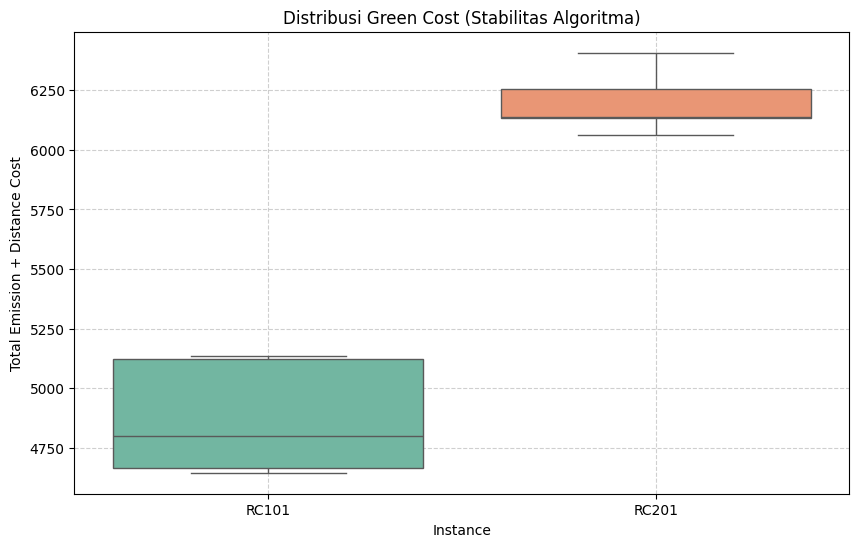

/tmp/ipykernel_17/4158048816.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Instance", y="Best_K", data=final_df, palette="coolwarm")


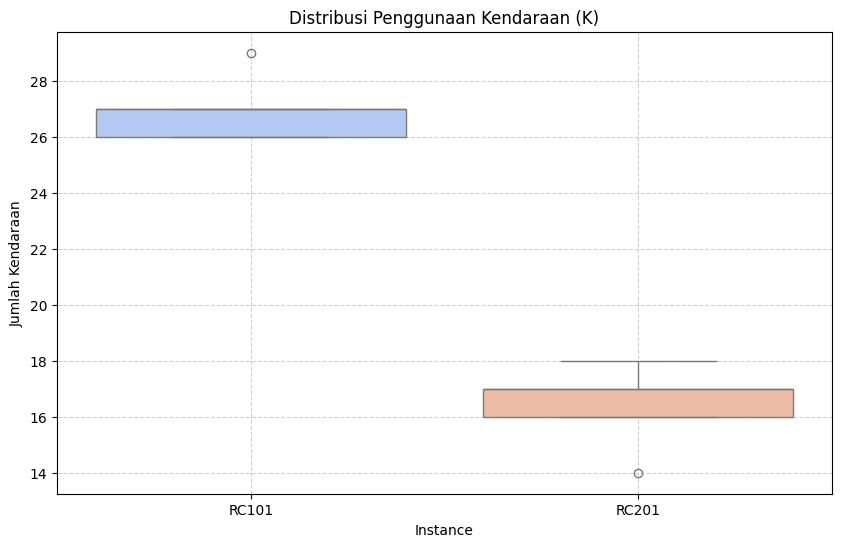

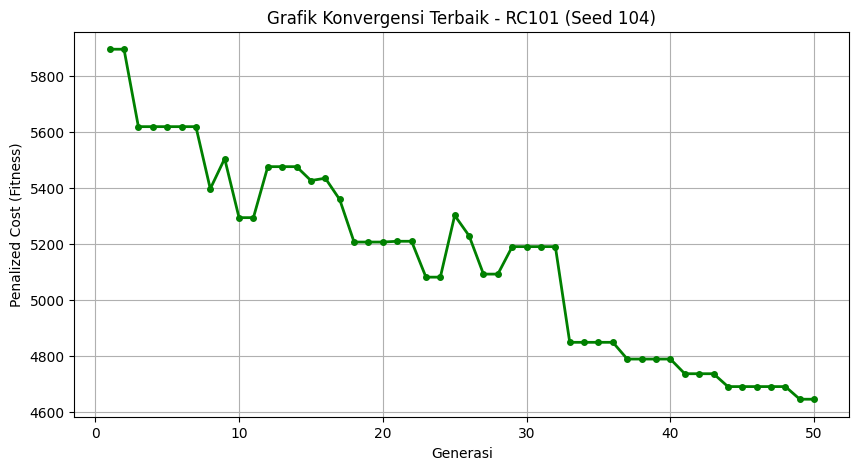

Grafik konvergensi untuk RC101 ditampilkan (diambil dari Run Seed 104).


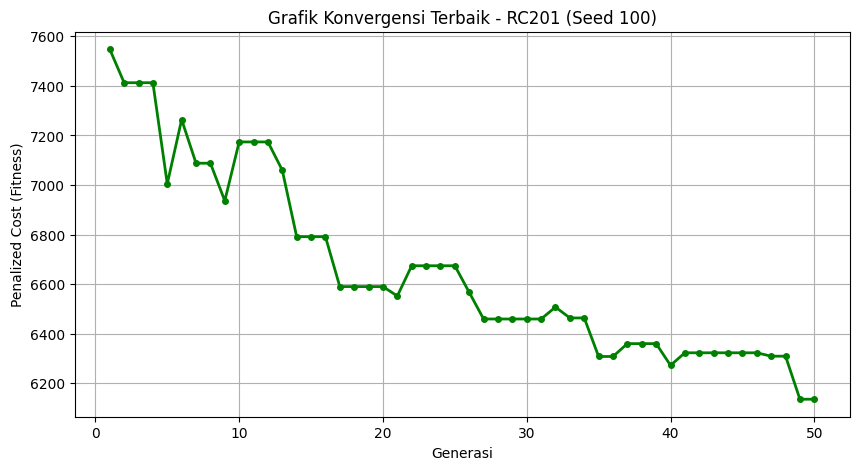

Grafik konvergensi untuk RC201 ditampilkan (diambil dari Run Seed 100).


In [34]:
# ==============================================================================
# CELL 25: VISUALISASI HASIL & EXPORT DATA (BAB 11)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ================================================================
# 11. Visualisasi Hasil Eksperimen
# ================================================================

print("="*70)
print("📊 GENERATING PLOTS & FINAL REPORT")
print("="*70)

# Pastikan ada hasil untuk diproses
if 'exp_results' not in globals() or not exp_results:
    print("❌ Tidak ada data eksperimen. Jalankan Cell 24 terlebih dahulu!")
else:
    # 1. AGGREGATE DATA KE SATU DATAFRAME BESAR
    all_runs_data = []
    for inst_name, res in exp_results.items():
        df_summary = res["summary_df"]
        all_runs_data.append(df_summary)

    final_df = pd.concat(all_runs_data, ignore_index=True)

    # Simpan ke CSV Utama
    csv_filename = "GreenVRP_Thesis_Final_Results.csv"
    final_df.to_csv(csv_filename, index=False)
    print(f"✅ Data lengkap tersimpan di: {csv_filename} (Silakan Download)")

    # Tampilkan Tabel Rekap
    print("\n--- REKAPITULASI AKHIR ---")
    display(final_df[["Instance", "Run", "Best_K", "Best_Cost_Green", "Is_Feasible", "Time_Sec"]])

    # ------------------------------------------------------------
    # GRAFIK 1: BOXPLOT KUALITAS SOLUSI (Cost Stability)
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Instance", y="Best_Cost_Green", data=final_df, palette="Set2")
    plt.title("Distribusi Green Cost (Stabilitas Algoritma)")
    plt.ylabel("Total Emission + Distance Cost")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # ------------------------------------------------------------
    # GRAFIK 2: BOXPLOT JUMLAH KENDARAAN (Vehicle Usage)
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Instance", y="Best_K", data=final_df, palette="coolwarm")
    plt.title("Distribusi Penggunaan Kendaraan (K)")
    plt.ylabel("Jumlah Kendaraan")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # ------------------------------------------------------------
    # GRAFIK 3: KONVERGENSI (SEJARAH EVOLUSI)
    # ------------------------------------------------------------
    # Kita ambil Run terbaik (Cost terendah) dari setiap Instance untuk diplot
    for inst_name, res in exp_results.items():
        runs = res["runs"]
        # Cari run terbaik (Feasible & Cost terendah)
        best_run = min(runs, key=lambda x: (not x["best_ind"].is_feasible, x["best_ind"].green_cost))

        hist = best_run["history"]
        if not hist: continue

        gens = [h["gen"] for h in hist]
        costs = [h["best_penalized_cost"] for h in hist] # Pakai penalized biar kelihatan turunnya

        plt.figure(figsize=(10, 5))
        plt.plot(gens, costs, marker='o', markersize=4, linestyle='-', linewidth=2, color='green')
        plt.title(f"Grafik Konvergensi Terbaik - {inst_name} (Seed {best_run['seed']})")
        plt.xlabel("Generasi")
        plt.ylabel("Penalized Cost (Fitness)")
        plt.grid(True)
        plt.show()

        print(f"Grafik konvergensi untuk {inst_name} ditampilkan (diambil dari Run Seed {best_run['seed']}).")

In [35]:
# ==============================================================================
# CELL 27: VISUALISASI PETA INTERAKTIF RC101 (ANT-PATH ANIMATION & LAYERS)
# ==============================================================================

# Install plugins jika belum
!pip install folium polyline requests -q

import folium
from folium import plugins
import requests
import polyline
import time
# ==============================================================================
# CELL 27 (FIXED): VISUALISASI FINAL DENGAN KOORDINAT VALID (NO MORE RIVER!)
# ==============================================================================

# Install plugins (jika perlu)
# !pip install folium polyline requests -q

import folium
from folium import plugins
import requests
import polyline
import time
import numpy as np # Wajib import numpy untuk baca NPZ

print("="*70)
print("🎬 MEMBUAT PETA INTERAKTIF (DATA SOURCE: NPZ VALID)...")
print("="*70)

# ============================================================
# 1. LOAD KOORDINAT 'KEBENARAN' DARI NPZ (CRITICAL STEP)
# ============================================================
# Ganti 'CORERC101NPZ' dengan path file .npz Anda yang valid
# Pastikan variabel CORERC101NPZ sudah didefinisikan di cell sebelumnya
try:
    with np.load(CORERC101NPZ) as data:
        real_latlon = data['latlon']       # [N, 2] Array Lat/Lon Asli
        real_demand = data['demandunits']  # [N,] Demand Asli
        is_depot = data['isdepot']         # [N,] Boolean

    # Ambil lokasi depot dari NPZ (Bukan settingan manual)
    depot_idx = np.where(is_depot)[0][0]
    depot_loc_valid = real_latlon[depot_idx]

    print("✅ Berhasil memuat koordinat valid dari NPZ.")
    print(f"   Lokasi Depot Valid: {depot_loc_valid}")

except NameError:
    print("❌ ERROR: Variabel 'CORERC101NPZ' belum didefinisikan.")
    print("   Pastikan Anda sudah menjalankan Cell Load Data.")
    raise
except Exception as e:
    print(f"❌ ERROR Loading NPZ: {e}")
    raise

# ============================================================
# 2. FUNGSI OSRM (ROUTING JALAN RAYA)
# ============================================================
def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
    # Menggunakan server publik OSRM (Demo server)
    url = f"http://router.project-osrm.org/route/v1/driving/{start_lon},{start_lat};{end_lon},{end_lat}?overview=full&geometries=polyline"
    try:
        r = requests.get(url, timeout=2)
        if r.status_code == 200:
            res = r.json()
            if 'routes' in res and len(res['routes']) > 0:
                return polyline.decode(res['routes'][0]['geometry'])
    except:
        pass
    # Fallback ke garis lurus jika OSRM gagal/timeout
    return [(start_lat, start_lon), (end_lat, end_lon)]

# ============================================================
# 3. PERSIAPAN DATA SOLUSI
# ============================================================
if 'exp_results' in globals() and 'RC101' in exp_results:
    # Ambil Run Terbaik
    runs = exp_results['RC101']['runs']
    best_run = min(runs, key=lambda x: (not x["best_ind"].is_feasible, x["best_ind"].green_cost))
    target_best_ind = best_run["best_ind"]
    target_problem = problemrc101 # Tetap butuh problem object untuk struktur data
    print(f"✅ Menggunakan Solusi Terbaik (Cost: {target_best_ind.green_cost:.2f})")
else:
    raise ValueError("❌ Harap jalankan eksperimen (Cell 24) terlebih dahulu.")

routes = target_best_ind.routes_repr

# ============================================================
# 4. MEMBANGUN PETA (DENGAN DATA NPZ)
# ============================================================

# Pusatkan peta di Depot Valid (dari NPZ)
m = folium.Map(location=depot_loc_valid, zoom_start=13, tiles='CartoDB positron')

colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6',
    '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3',
    '#808000', '#ffd8b1', '#000075', '#808080', '#000000'
]

print(f"🚀 Menggambar {len(routes)} rute...")

# Loop Rute
for i, (vtype_idx, route_custs) in enumerate(routes):
    layer_name = f"Vehicle {i+1} (Type {vtype_idx})"
    fg = folium.FeatureGroup(name=layer_name, show=True)
    color = colors[i % len(colors)]

    # --- TITIK AWAL (DEPOT) ---
    # AMBIL DARI NPZ LANGSUNG! JANGAN DIHITUNG LAGI!
    prev_node = 0 # Node 0 adalah depot
    prev_lat, prev_lon = real_latlon[prev_node]

    # Marker Depot (Hanya sekali di layer dasar)
    if i == 0:
        folium.Marker(
            [prev_lat, prev_lon],
            popup="<b>DEPOT UTAMA</b>",
            icon=folium.Icon(color='black', icon='home', prefix='fa')
        ).add_to(m)

    path_coords = []
    # Sequence: Cust 1 -> Cust 2 -> ... -> Depot (0)
    full_sequence = route_custs + [0]
    total_load = 0

    # --- KONSTRUKSI GEOMETRI ---
    for next_node in full_sequence:
        # AMBIL KOORDINAT DARI NPZ (THE FIX!)
        curr_lat, curr_lon = real_latlon[next_node]

        # Ambil demand (dari NPZ juga biar konsisten)
        if next_node != 0:
            dem = real_demand[next_node]
            total_load += dem

            # Marker Customer
            folium.CircleMarker(
                location=[curr_lat, curr_lon],
                radius=5,
                color=color,
                fill=True, fill_color='white', fill_opacity=1,
                tooltip=f"Cust {next_node} (Load: {dem})",
                popup=f"<b>Customer {next_node}</b><br>Lat/Lon: {curr_lat:.5f},{curr_lon:.5f}<br>Demand: {dem}"
            ).add_to(fg)

        # Tarik Garis OSRM
        segment = get_osrm_route(prev_lat, prev_lon, curr_lat, curr_lon)
        path_coords.extend(segment)

        # Update node sebelumnya
        prev_lat, prev_lon = curr_lat, curr_lon

        # Sedikit delay biar API OSRM tidak marah
        time.sleep(0.01)

    # --- ANT PATH (ANIMASI) ---
    plugins.AntPath(
        locations=path_coords,
        color=color,
        weight=4,
        opacity=0.8,
        delay=1000,
        dash_array=[10, 20],
        pulse_color='white',
        hardware_acceleration=True,
        tooltip=f"<b>Vehicle {i+1}</b>",
        popup=f"Vehicle {i+1} | Load: {total_load}"
    ).add_to(fg)

    fg.add_to(m)
    if (i+1) % 5 == 0: print(f"   ... Rute {i+1} selesai.")

# 5. CONTROL & SAVE
folium.LayerControl(collapsed=True).add_to(m)
filename = "Peta_Final_Corrected_RC101.html"
m.save(filename)

print("="*70)
print("✅ PETA RC101 SELESAI! ")
print(f"File: {filename}")
print("="*70)

m

🎬 MEMBUAT PETA INTERAKTIF (DATA SOURCE: NPZ VALID)...
✅ Berhasil memuat koordinat valid dari NPZ.
   Lokasi Depot Valid: [ -7.57103944 110.82968937]
✅ Menggunakan Solusi Terbaik (Cost: 4644.59)
🚀 Menggambar 26 rute...
   ... Rute 5 selesai.
   ... Rute 10 selesai.
   ... Rute 15 selesai.
   ... Rute 20 selesai.
   ... Rute 25 selesai.
✅ PETA RC101 SELESAI! 
File: Peta_Final_Corrected_RC101.html


In [36]:
# ==============================================================================
# VISUALISASI FINAL RC201 (DENGAN KOORDINAT VALID NPZ)
# ==============================================================================

import folium
from folium import plugins
import requests
import polyline
import time
import numpy as np

print("="*70)
print("🎬 MEMBUAT PETA INTERAKTIF RC201 ...")
print("="*70)

# ============================================================
# 1. LOAD KOORDINAT VALID DARI NPZ (RC201)
# ============================================================
# Pastikan variabel CORERC201NPZ sudah ada (dari step Load Data)
try:
    with np.load(CORERC201NPZ) as data:
        real_latlon = data['latlon']       # [N, 2]
        real_demand = data['demandunits']  # [N,]
        is_depot = data['isdepot']         # [N,] Boolean

    depot_idx = np.where(is_depot)[0][0]
    depot_loc_valid = real_latlon[depot_idx]

    print("✅ Berhasil memuat koordinat valid RC201.")

except NameError:
    print("❌ ERROR: Variabel 'CORERC201NPZ' tidak ditemukan.")
    print("   Pastikan path file NPZ sudah benar.")
    raise
except Exception as e:
    print(f"❌ ERROR Loading NPZ: {e}")
    raise

# ============================================================
# 2. FUNGSI OSRM
# ============================================================
def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
    url = f"http://router.project-osrm.org/route/v1/driving/{start_lon},{start_lat};{end_lon},{end_lat}?overview=full&geometries=polyline"
    try:
        r = requests.get(url, timeout=2)
        if r.status_code == 200:
            res = r.json()
            if 'routes' in res and len(res['routes']) > 0:
                return polyline.decode(res['routes'][0]['geometry'])
    except:
        pass
    return [(start_lat, start_lon), (end_lat, end_lon)]

# ============================================================
# 3. AMBIL SOLUSI TERBAIK RC201
# ============================================================
if 'exp_results' in globals() and 'RC201' in exp_results:
    runs = exp_results['RC201']['runs']
    # Cari run terbaik (Cost terendah & Feasible)
    best_run = min(runs, key=lambda x: (not x["best_ind"].is_feasible, x["best_ind"].green_cost))
    target_best_ind = best_run["best_ind"]

    # Ambil struktur rute
    routes = target_best_ind.routes_repr
    print(f"✅ Menggunakan Solusi Terbaik RC201 (Cost: {target_best_ind.green_cost:.2f})")
else:
    raise ValueError("❌ Harap jalankan eksperimen RC201 (Cell 24) terlebih dahulu.")

# ============================================================
# 4. GAMBAR PETA
# ============================================================
m = folium.Map(location=depot_loc_valid, zoom_start=13, tiles='CartoDB positron')

colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6',
    '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3'
]

print(f"🚀 Menggambar {len(routes)} rute...")

for i, (vtype_idx, route_custs) in enumerate(routes):
    # Ambil nama kendaraan dari config problem (jika ada variabel global problems)
    # Atau kita tebak dari index: 0=Motor, 1=Van, 2=Truk
    v_name = "Kendaraan"
    if vtype_idx == 0: v_name = "MOTOR"
    elif vtype_idx == 1: v_name = "VAN"
    elif vtype_idx == 2: v_name = "TRUCK"

    layer_name = f"Rute {i+1}: {v_name}"
    fg = folium.FeatureGroup(name=layer_name, show=True)
    color = colors[i % len(colors)]

    # --- TITIK AWAL (DEPOT) ---
    prev_node = 0
    prev_lat, prev_lon = real_latlon[prev_node]

    if i == 0:
        folium.Marker(
            [prev_lat, prev_lon],
            popup="<b>DEPOT UTAMA</b>",
            icon=folium.Icon(color='black', icon='home', prefix='fa')
        ).add_to(m)

    path_coords = []
    full_sequence = route_custs + [0]
    total_load = 0

    # --- GEOMETRI RUTE ---
    for next_node in full_sequence:
        curr_lat, curr_lon = real_latlon[next_node]

        if next_node != 0:
            dem = real_demand[next_node]
            total_load += dem

            folium.CircleMarker(
                location=[curr_lat, curr_lon],
                radius=6 if vtype_idx == 2 else 4, 
                color=color,
                fill=True, fill_color='white', fill_opacity=1,
                tooltip=f"Cust {next_node}",
                popup=f"<b>Cust {next_node}</b><br>Load: {dem}<br>Via: {v_name}"
            ).add_to(fg)

        segment = get_osrm_route(prev_lat, prev_lon, curr_lat, curr_lon)
        path_coords.extend(segment)
        prev_lat, prev_lon = curr_lat, curr_lon
        time.sleep(0.01)

    # --- ANIMASI ANT-PATH ---
    plugins.AntPath(
        locations=path_coords,
        color=color,
        weight=5 if vtype_idx == 2 else 3, 
        opacity=0.8,
        delay=1200 if vtype_idx == 2 else 800, 
        dash_array=[10, 20],
        pulse_color='white',
        hardware_acceleration=True,
        tooltip=f"<b>{v_name} {i+1}</b>",
        popup=f"{v_name} | Total Load: {total_load}"
    ).add_to(fg)

    fg.add_to(m)

# 5. SAVE
folium.LayerControl(collapsed=True).add_to(m)
filename = "Peta_Final_Corrected_RC201.html"
m.save(filename)

print("="*70)
print("✅ PETA RC201 SELESAI!")
print(f"File: {filename}")
print("="*70)

m

🎬 MEMBUAT PETA INTERAKTIF RC201 ...
✅ Berhasil memuat koordinat valid RC201.
✅ Menggunakan Solusi Terbaik RC201 (Cost: 6136.08)
🚀 Menggambar 14 rute...
✅ PETA RC201 SELESAI!
File: Peta_Final_Corrected_RC201.html


In [37]:
# # ==============================================================================
# # CELL 28: VISUALISASI PETA INTERAKTIF RC201 (ANT-PATH ANIMATION & LAYERS)
# # ==============================================================================

# import folium
# from folium import plugins
# import requests
# import polyline
# import time

# print("="*70)
# print("🎬 MEMBUAT PETA INTERAKTIF UNTUK RC201...")
# print("="*70)

# # ============================================================
# # 1. SETUP DATA & KONFIGURASI
# # ============================================================
# SOLO_LAT = -7.571039442121335
# SOLO_LON = 110.82968937197799
# SCALE_FACTOR = 0.0006

# # Fungsi Bantu (Kita definisikan lagi agar cell ini mandiri)
# def get_node_coords(problem, index):
#     if hasattr(problem, 'coords'):
#         c = problem.coords[index]
#         return c[0], c[1]
#     raise AttributeError(f"Data koordinat tidak ditemukan.")

# def project_xy_to_latlon(x, y, problem):
#     depot_x, depot_y = get_node_coords(problem, 0)
#     dx = x - depot_x
#     dy = y - depot_y
#     return SOLO_LAT + (dy * SCALE_FACTOR), SOLO_LON + (dx * SCALE_FACTOR)

# def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
#     url = f"http://router.project-osrm.org/route/v1/driving/{start_lon},{start_lat};{end_lon},{end_lat}?overview=full&geometries=polyline"
#     try:
#         # Timeout sedikit lebih lama jaga-jaga rute panjang
#         r = requests.get(url, timeout=5)
#         if r.status_code == 200:
#             res = r.json()
#             if 'routes' in res and len(res['routes']) > 0:
#                 return polyline.decode(res['routes'][0]['geometry'])
#     except:
#         pass
#     return [(start_lat, start_lon), (end_lat, end_lon)]

# # ============================================================
# # 2. PERSIAPAN DATA SOLUSI (KHUSUS RC201)
# # ============================================================
# TARGET_INSTANCE = 'RC201'

# if 'exp_results' in globals() and TARGET_INSTANCE in exp_results:
#     runs = exp_results[TARGET_INSTANCE]['runs']
#     # Cari run terbaik
#     best_run = min(runs, key=lambda x: (not x["best_ind"].is_feasible, x["best_ind"].green_cost))
#     target_best_ind = best_run["best_ind"]
#     target_problem = problemrc201  # <--- Pastikan pakai data RC201

#     print(f"Menggunakan solusi terbaik {TARGET_INSTANCE} (Run Seed {best_run['seed']})")
#     print(f"Jumlah Rute (K): {target_best_ind.n_routes}")
#     print(f"Feasible: {target_best_ind.is_feasible}")
# else:
#     raise ValueError(f"Data hasil eksperimen untuk {TARGET_INSTANCE} tidak ditemukan! Pastikan sudah run eksperimen.")

# target_best_ind.ensure_evaluated()
# routes = target_best_ind.routes_repr

# # ============================================================
# # 3. MEMBANGUN PETA
# # ============================================================
# m = folium.Map(location=[SOLO_LAT, SOLO_LON], zoom_start=13, tiles='CartoDB positron')

# colors = [
#     '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6',
#     '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3',
#     '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff', '#000000'
# ]

# print(f"Sedang menggambar {len(routes)} rute...")

# for i, (vtype_idx, route_custs) in enumerate(routes):
#     layer_name = f"Vehicle {i+1} (Type {vtype_idx})"
#     fg = folium.FeatureGroup(name=layer_name, show=True)

#     color = colors[i % len(colors)]

#     # Depot Awal
#     prev_node = 0
#     prev_x, prev_y = get_node_coords(target_problem, prev_node)
#     prev_lat, prev_lon = project_xy_to_latlon(prev_x, prev_y, target_problem)

#     if i == 0:
#         folium.Marker(
#             [prev_lat, prev_lon],
#             popup="<b>DEPOT UTAMA</b>",
#             icon=folium.Icon(color='black', icon='home', prefix='fa')
#         ).add_to(m)

#     path_coords = []
#     full_sequence = route_custs + [0]
#     total_load = 0

#     for next_node in full_sequence:
#         curr_x, curr_y = get_node_coords(target_problem, next_node)
#         curr_lat, curr_lon = project_xy_to_latlon(curr_x, curr_y, target_problem)

#         if next_node != 0:
#             dem = target_problem.demand_units[next_node]
#             total_load += dem

#             folium.CircleMarker(
#                 location=[curr_lat, curr_lon],
#                 radius=5,
#                 color=color,
#                 fill=True,
#                 fill_color='white',
#                 fill_opacity=1,
#                 tooltip=f"Cust {next_node}",
#                 popup=f"RC201 Cust {next_node}<br>Load: {dem}"
#             ).add_to(fg)

#         # Tarik Garis
#         segment = get_osrm_route(prev_lat, prev_lon, curr_lat, curr_lon)
#         path_coords.extend(segment)

#         prev_lat, prev_lon = curr_lat, curr_lon
#         time.sleep(0.02) # Jeda sopan untuk server OSRM

#     # Animasi AntPath
#     plugins.AntPath(
#         locations=path_coords,
#         color=color,
#         weight=4,
#         opacity=0.8,
#         delay=1000,
#         dash_array=[10, 20],
#         pulse_color='white',
#         hardware_acceleration=True,
#         tooltip=f"<b>Vehicle {i+1}</b> (RC201)",
#         popup=f"Vehicle {i+1}<br>Type: {vtype_idx}<br>Load: {total_load}"
#     ).add_to(fg)

#     fg.add_to(m)
#     print(f"  ✓ Rute {i+1} selesai.")

# # Layer Control
# folium.LayerControl(collapsed=True).add_to(m)

# # Simpan dengan nama file BEDA agar tidak menimpa RC101
# filename = "Peta_Interaktif_Surakarta_RC201.html"
# m.save(filename)

# print("="*70)
# print(f"✅ VISUALISASI RC201 SELESAI!")
# print(f"File peta tersimpan sebagai: {filename}")
# print("Silakan download dan bandingkan dengan RC101.")
# print("="*70)

# m

In [38]:
# # Ambil satu sampel solusi dari hasil RC101
# try:
#     sample_run = exp_results["RC101"]["runs"][0]
#     ind = sample_run["best_ind"]

#     print("=== INFO DEBUG STRUKTUR INDIVIDUAL ===")

#     # Cek routes_repr
#     if hasattr(ind, 'routes_repr'):
#         print(f"1. Tipe 'routes_repr': {type(ind.routes_repr)}")
#         print(f"   Isi 'routes_repr': {ind.routes_repr}")
#     else:
#         print("1. 'routes_repr' TIDAK ADA.")

#     # Cek giant_tour
#     if hasattr(ind, 'giant_tour'):
#         print(f"\n2. Tipe 'giant_tour': {type(ind.giant_tour)}")
#         print(f"   Isi 'giant_tour' (10 depan): {ind.giant_tour[:10] if isinstance(ind.giant_tour, list) else ind.giant_tour}")
#     else:
#         print("\n2. 'giant_tour' TIDAK ADA.")

#     # Cek akses Problem
#     if hasattr(ind, 'problem'):
#         print("\n3. Atribut 'problem' DITEMUKAN dalam Individual.")
#     else:
#         print("\n3. Atribut 'problem' TIDAK ADA (Harus pakai dictionary eksternal).")

# except Exception as e:
#     print(f"❌ Terjadi error saat debug: {e}")

In [39]:
# # Ambil satu sampel problem
# try:
#     # Ambil problem dari hasil run pertama
#     run_data = exp_results["RC101"]["runs"][0]
#     prob = run_data["best_ind"].problem

#     print("=== ISI ATRIBUT PROBLEMDATA ===")
#     # Tampilkan semua atribut yang tidak diawali '__'
#     attrs = [attr for attr in dir(prob) if not attr.startswith('__')]
#     print(attrs)

#     print("\n=== CEK KANDIDAT DEMAND ===")
#     # Cek apakah ada atribut yang mirip-mirip 'demand'
#     for a in attrs:
#         if 'demand' in a.lower() or 'cap' in a.lower() or 'node' in a.lower():
#             val = getattr(prob, a)
#             print(f"👉 prob.{a} : {type(val)}")

# except Exception as e:
#     print(f"Error Debug: {e}")

In [40]:
# ==============================================================================
# FUNGSI INSPEKSI DETAIL SOLUSI (FIXED: CAPACITY_UNITS)
# ==============================================================================
import numpy as np

def inspect_solution_final(exp_results, instance_name, run_index=0):
    """
    Menampilkan detail rute, muatan, dan jenis kendaraan.
    Fixed: Menggunakan 'capacity_units' sesuai JSON fleet.
    """
    # 1. Validasi Input
    if instance_name not in exp_results:
        print(f"❌ Error: Hasil '{instance_name}' tidak ditemukan di exp_results.")
        return

    # 2. Ambil Data
    try:
        run_data = exp_results[instance_name]["runs"][run_index]
        ind = run_data["best_ind"]
        seed = run_data["seed"]

        # Ambil Object Problem & Rute
        prob = ind.problem
        raw_routes = ind.routes_repr

    except Exception as e:
        print(f"❌ Error mengambil data: {e}")
        return

    # 3. Header Laporan
    print("="*80)
    print(f"📊 DETAIL SOLUSI: {instance_name} | Run #{run_index+1} (Seed {seed})")
    print("="*80)

    sc = ind.solution_cost
    status = "✅ LAYAK" if ind.is_feasible else "❌ TIDAK LAYAK"

    print(f"Status       : {status}")
    print(f"Total Cost   : {ind.green_cost:.2f}")
    print(f"Total Emisi  : {sc.total_moving_emission + sc.total_idle_emission:.2f} gCO2")
    print("-" * 80)

    # 4. Analisis Detail Per Rute
    total_dist_check = 0
    total_load_check = 0

    # Urutkan berdasarkan index kendaraan (0=Motor, 1=Van, 2=Truk)
    sorted_routes = sorted(raw_routes, key=lambda x: x[0])

    for i, (v_idx, route_nodes_np) in enumerate(sorted_routes):
        route_nodes = [int(x) for x in route_nodes_np]

        # Ambil Tipe Kendaraan
        vt = prob.fleet_config.vehicle_types[v_idx]

        # --- SAFE ACCESS ATTRIBUTES (Anti-Error) ---
        # Cek apakah namanya 'capacity' atau 'capacity_units'
        cap = getattr(vt, 'capacity_units', getattr(vt, 'capacity', 0))

        # Ambil Nama (Default 'Unknown')
        v_name = getattr(vt, 'name', 'Unknown').upper()

        # --- HITUNG MANUAL METRIK ---
        dist = 0
        load = 0
        duration = 0
        full_path = [0] + route_nodes + [0]

        for k in range(len(full_path) - 1):
            u = full_path[k]
            v = full_path[k+1]
            dist += prob.dist_matrix[u][v]
            duration += prob.travel_time_matrix[u][v]
            if v != 0:
                # Akses demand_units (Numpy Array)
                load += prob.demand_units[v]
                duration += prob.service_time[v]

        # --- TAMPILKAN ---
        emission_est = dist * 1.0 

        route_str = "->".join(map(str, route_nodes))
        if len(route_str) > 85: route_str = route_str[:85] + "..."

        # Visualisasi Bar Kapasitas
        if cap > 0:
            load_pct = (load / cap) * 100
            bars = int(load_pct / 10)
            load_bar = "█" * bars + "░" * (10 - bars)
        else:
            load_pct = 0
            load_bar = "ERROR (Cap=0)"

        print(f"🚚 RUTE #{i+1} | Tipe: {v_name} (Cap: {cap:.0f})")
        print(f"   ├─ Muatan    : {load:.0f} unit ({load_pct:.1f}%) {load_bar}")
        print(f"   ├─ Statistik : Jarak {dist:.1f} km | Durasi {duration:.1f} min")
        print(f"   ├─ Emisi     : ~{emission_est:.1f}")
        print(f"   └─ Jalur     : Depot->{route_str}->Depot")
        print("-" * 40)

        total_dist_check += dist
        total_load_check += load

    print("="*80)
    print(f"🔍 Validasi Total:")
    print(f"   Total Jarak  : {total_dist_check:.1f} km")
    print(f"   Total Muatan : {total_load_check:.0f} unit")
    print("="*80)

# ==============================================================================
# JALANKAN CHECKER
# ==============================================================================

print("\n>>> MEMERIKSA RC101 <<<")
inspect_solution_final(exp_results, "RC101", run_index=0)

print("\n\n>>> MEMERIKSA RC201 <<<")
inspect_solution_final(exp_results, "RC201", run_index=0)


>>> MEMERIKSA RC101 <<<
📊 DETAIL SOLUSI: RC101 | Run #1 (Seed 100)
Status       : ✅ LAYAK
Total Cost   : 5122.57
Total Emisi  : 3818.85 gCO2
--------------------------------------------------------------------------------
🚚 RUTE #1 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Muatan    : 36 unit (60.0%) ██████░░░░
   ├─ Statistik : Jarak 139.8 km | Durasi 85.9 min
   ├─ Emisi     : ~139.8
   └─ Jalur     : Depot->90->7->24->Depot
----------------------------------------
🚚 RUTE #2 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Muatan    : 20 unit (33.3%) ███░░░░░░░
   ├─ Statistik : Jarak 103.2 km | Durasi 61.3 min
   ├─ Emisi     : ~103.2
   └─ Jalur     : Depot->45->3->Depot
----------------------------------------
🚚 RUTE #3 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Muatan    : 54 unit (90.0%) █████████░
   ├─ Statistik : Jarak 116.4 km | Durasi 86.6 min
   ├─ Emisi     : ~116.4
   └─ Jalur     : Depot->27->67->85->94->Depot
----------------------------------------
🚚 RUTE #4 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Mu